In [1]:
# =========================================================
# STAGE 0: IMPORTS AND BASIC SETUP
# =========================================================
import os
import re
import numpy as np
import torch
import transformers

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optional: disable wandb logging
os.environ["WANDB_DISABLED"] = "true"

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# ============================================================
# STAGE 1: LOAD DATASET
# ============================================================

import pandas as pd
from datasets import Dataset

# ------------------------------------------------------------
# STEP 1.1: LOAD CSV FROM KAGGLE INPUT PATH
# ------------------------------------------------------------

csv_path = "/kaggle/input/datasets/kezheonglim/recipe-new/dataset_filtered_20_plus_target_per_serve.csv"
df = pd.read_csv(csv_path)

print("✅ CSV loaded successfully.")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))


# ------------------------------------------------------------
# STEP 1.2: DEFINE LABEL COLUMN CLEARLY
# ------------------------------------------------------------

label_column = "sugar_per_serving_g"   # change here if needed

if label_column not in df.columns:
    raise ValueError(
        f"❌ Label column '{label_column}' not found.\n"
        f"Available columns: {df.columns.tolist()}"
    )

print(f"\n✅ Using label column: {label_column}")


# ------------------------------------------------------------
# STEP 1.3: DEFINE FEATURE COLUMNS
# Use all columns except the label column
# ------------------------------------------------------------

feature_columns = [col for col in df.columns if col != label_column]

print(f"✅ Number of feature columns: {len(feature_columns)}")
print("✅ Feature columns:", feature_columns)


# ------------------------------------------------------------
# STEP 1.4: OPTIONAL - FILL MISSING VALUES
# Text columns -> empty string
# Numeric columns -> median
# ------------------------------------------------------------

for col in feature_columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("").astype(str)
    else:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].fillna(df[col].median())

df[label_column] = pd.to_numeric(df[label_column], errors="coerce")
df = df.dropna(subset=[label_column]).copy()

print("\n✅ Missing values handled.")


# ------------------------------------------------------------
# STEP 1.5: COMBINE ALL FEATURES INTO ONE TEXT COLUMN
# This allows a text model to use all columns
# ------------------------------------------------------------

def combine_features(row):
    parts = []
    for col in feature_columns:
        parts.append(f"{col}: {row[col]}")
    return " | ".join(parts)

df["text"] = df.apply(combine_features, axis=1)
df["labels"] = df[label_column].astype(float)

print("\n✅ Combined all feature columns into 'text'")
print(df[["text", "labels"]].head(2))


# ------------------------------------------------------------
# STEP 1.6: KEEP ONLY MODEL-READY COLUMNS
# ------------------------------------------------------------

df_model = df[["text", "labels"]].copy()

print("\n✅ Final model dataframe ready.")
print("Final columns:", df_model.columns.tolist())
print(df_model.head(3))


# ------------------------------------------------------------
# STEP 1.7: CONVERT DATAFRAME TO HUGGING FACE DATASET
# ------------------------------------------------------------

dataset = Dataset.from_pandas(df_model)

if "__index_level_0__" in dataset.column_names:
    dataset = dataset.remove_columns(["__index_level_0__"])

print("\n✅ Converted to Hugging Face Dataset.")
print("Dataset columns:", dataset.column_names)


# ------------------------------------------------------------
# STEP 1.8: SPLIT INTO TRAIN / TEST
# ------------------------------------------------------------

dataset = dataset.train_test_split(test_size=0.2, seed=42)

print("\n✅ Train-test split completed.")
print("Train size:", len(dataset["train"]))
print("Test size :", len(dataset["test"]))


# ------------------------------------------------------------
# STEP 1.9: CREATE TRAIN / TEST REFERENCES
# ------------------------------------------------------------

train_dataset = dataset["train"]
test_dataset = dataset["test"]

print("\n✅ Stage 1 completed successfully.")
print("Train samples:", len(train_dataset))
print("Test samples :", len(test_dataset))


# ------------------------------------------------------------
# STEP 1.10: SANITY CHECK
# ------------------------------------------------------------

print("\n✅ Sample records:")
for i in range(min(3, len(train_dataset))):
    print(f"\nSample {i+1}")
    print("Text  :", train_dataset[i]["text"][:500])  # print first 500 chars
    print("Label :", train_dataset[i]["labels"])

✅ CSV loaded successfully.
Shape: (27638, 20)
Columns: ['recipe_name', 'ingredients', 'servings', 'STARCH', 'FIBTG', 'WATER', 'FAT', 'PROCNT', 'CHOCDF', 'ENERC_KCAL', 'SUCS', 'GLUS', 'FRUS', 'LACS', 'MALS', 'GALS', 'CHOLE', 'ASH', 'CAFFN', 'sugar_per_serving_g']
                           recipe_name  \
0                     Mushroom Risotto   
1            Filipino BBQ Pork Skewers   
2  Mushroom and Roasted Garlic Risotto   

                                         ingredients  servings  STARCH  FIBTG  \
0  2 cups Baby Bella mushrooms, sliced, 2 cups ar...       6.0    0.02   2.85   
1  2.5 lb pork country style ribs, all fat trimme...       4.0     NaN   3.25   
2  2 whole garlic heads, 2 tablespoons plus 2 tea...       1.0     NaN  34.70   

     WATER    FAT  PROCNT  CHOCDF  ENERC_KCAL   SUCS  GLUS  FRUS  LACS  MALS  \
0   400.14   8.54   19.14   75.34      476.93    NaN  0.34  0.02   NaN   NaN   
1   308.85  34.93   56.97   26.21      650.03  11.83  1.40  2.25   NaN   NaN   
2  

In [3]:
# ============================================================
# STAGE 2: EDA
# - columns were loaded correctly
# - text and numeric fields are in the right format
# - there are repeated recipes that may distort training
# ============================================================

# ==========================
# A. Basic structure check
# ==========================
# print(df.shape)
# print(df.columns.tolist())
# print(df.dtypes)
# print(df.duplicated().sum())
# print(df["recipe_name"].duplicated().sum())

# ==========================
# B. Missing value analysis
# ==========================
# missing = df.isnull().sum().sort_values(ascending=False)
# missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

# missing_df = pd.DataFrame({
#     "missing_count": missing,
#     "missing_pct": missing_pct
# })
# print(missing_df)


# ==========================
# C. Invalid value check
# ==========================
num_cols = ["servings", "STARCH", "FIBTG", "WATER", "FAT", "PROCNT",
            "CHOCDF", "ENERC_KCAL", "SUCS", "GLUS", "FRUS",
            "LACS", "MALS", "GALS", "CHOLE", "ASH", "CAFFN",
            "sugar_per_serving_g"]

print(df[num_cols].describe().T)

                       count        mean          std   min     25%  \
servings             24880.0    7.608320    17.695142  1.00    4.00   
STARCH               24880.0    6.414824    23.372020  0.00    1.09   
FIBTG                24880.0    5.797941    16.391312  0.00    1.59   
WATER                24880.0  232.531642   302.683434  0.01   94.71   
FAT                  24880.0   25.073544    87.308385  0.00    7.84   
PROCNT               24880.0   25.014506   206.123391  0.00    4.82   
CHOCDF               24880.0   45.836211   121.799881  0.00   14.46   
ENERC_KCAL           24880.0  502.057329  1592.980044  0.90  206.31   
SUCS                 24880.0    4.678770    19.542569  0.00    0.28   
GLUS                 24880.0    1.646520     3.688535  0.00    0.46   
FRUS                 24880.0    1.572594     3.654950  0.00    0.38   
LACS                 24880.0    0.894750     1.318484  0.01    0.79   
MALS                 24880.0    0.436124     0.570962  0.00    0.37   
GALS  

In [4]:
# ============================================================
# STAGE 2: PREPROCESSING (TEXT NORMALIZATION + SUGAR STANDARDIZATION)
# ============================================================

import unicodedata
from fractions import Fraction
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# STEP 2.0: CONFIGURATION
# ------------------------------------------------------------

# choose one target only
TARGET_COLUMN = "labels"          # already created in Stage 1
USE_LOG_TARGET = True             # set True to use log1p(labels) instead of raw clipped labels
USE_TARGET_CLIPPING = True        # cap extreme sugar values, this reduces the influence of abnormal nutrition records.
CLIP_QUANTILE = 0.99              # clip at 99th percentile
CLIP_FEATURES = True              # clip numeric features using train percentiles
NORMALIZE_FEATURES = True         # standardize numeric features
PRINT_EXTREME_ROWS = True         # inspect suspicious rows

# numeric columns that exist in your dataset and should be used
CANDIDATE_NUMERIC_FEATURES = [
    "servings", "STARCH", "FIBTG", "WATER", "FAT", "PROCNT",
    "CHOCDF", "ENERC_KCAL", "SUCS", "GLUS", "FRUS",
    "LACS", "MALS", "GALS", "CHOLE", "ASH", "CAFFN"
]

# text columns you want to preserve
TEXT_SOURCE_COLUMN = "text"       # from Stage 1, this is the model input text source

# ------------------------------------------------------------
# STEP 2.1: HANDLE SPECIAL CHARACTERS & FRACTIONS
# Convert strange characters like “½”, “å”, “¨” → clean ASCII
# ------------------------------------------------------------

UNICODE_FRACTIONS = {
    "¼": "1/4", "½": "1/2", "¾": "3/4",
    "⅐": "1/7", "⅑": "1/9", "⅒": "1/10",
    "⅓": "1/3", "⅔": "2/3",
    "⅕": "1/5", "⅖": "2/5", "⅗": "3/5", "⅘": "4/5",
    "⅙": "1/6", "⅚": "5/6",
    "⅛": "1/8", "⅜": "3/8", "⅝": "5/8", "⅞": "7/8",
}

def strip_accents_and_symbols(text: str) -> str:
    """Remove weird unicode characters and normalize text."""
    if text is None:
        return ""

    text = str(text)

    # Replace unicode fractions
    for bad, good in UNICODE_FRACTIONS.items():
        text = text.replace(bad, good)

    # Normalize unicode → ASCII
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")

    # Clean leftover symbols
    text = text.replace("`", "").replace("´", "").replace("¨", "")
    text = text.replace("’", "'").replace("‘", "'").replace("“", '"').replace("”", '"')
    text = text.replace("–", "-").replace("—", "-")

    return text


# ------------------------------------------------------------
# STEP 2.2: NORMALIZE BASIC TEXT
# Standardize units & clean format (DO NOT REMOVE NUMBERS)
# ------------------------------------------------------------

GENERAL_UNIT_NORMALIZATION = {
    "tablespoons": "tbsp", "tablespoon": "tbsp", "tbs": "tbsp", "tbl": "tbsp",
    "teaspoons": "tsp", "teaspoon": "tsp",
    "ounces": "oz", "ounce": "oz",
    "pounds": "lb", "pound": "lb", "lbs": "lb",
    "grams": "g", "gram": "g",
    "kilograms": "kg", "kilogram": "kg",
    "cups": "cup",
}

def normalize_basic_text(text: str) -> str:
    """Lowercase, normalize units, remove noise."""
    text = strip_accents_and_symbols(text)
    text = text.lower()

    # Remove URLs if any
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Normalize units (tablespoons → tbsp)
    for src, tgt in GENERAL_UNIT_NORMALIZATION.items():
        text = re.sub(rf"\b{re.escape(src)}\b", tgt, text)

    # Keep numbers, fractions, units → remove only unwanted symbols
    text = re.sub(r"[^a-z0-9\s,./()\-]", " ", text)

    # Clean spacing
    text = re.sub(r"\s+", " ", text).strip()

    return text


# ------------------------------------------------------------
# STEP 2.3: PARSE NUMERIC QUANTITIES
# Support formats:
# - 1
# - 1.5
# - 1/2
# - 1 1/2
# ------------------------------------------------------------

def parse_quantity(qty_text: str) -> float:
    qty_text = qty_text.strip()

    # Mixed fraction: 1 1/2
    if re.fullmatch(r"\d+\s+\d+/\d+", qty_text):
        whole, frac = qty_text.split()
        return float(whole) + float(Fraction(frac))

    # Fraction: 1/2
    if re.fullmatch(r"\d+/\d+", qty_text):
        return float(Fraction(qty_text))

    # Decimal / integer
    return float(qty_text)


# ------------------------------------------------------------
# STEP 2.4: STANDARDIZE SUGAR QUANTITY INTO GRAMS
# Keep ingredient identity + normalized quantity
# ------------------------------------------------------------

SUGAR_WORDS = [
    "brown sugar", "white sugar", "caster sugar", "granulated sugar",
    "icing sugar", "powdered sugar", "confectioners sugar",
    "raw sugar", "demerara sugar", "coconut sugar", "palm sugar",
    "sugar", 
]

# high sweeteners
HIGH_SWEETENER_WORDS = [
    "honey", "maple syrup", "corn syrup", "golden syrup", "chocolate syrup",
    "syrup", "molasses", "condensed milk", "sweetened condensed milk", "caramel",
]

# medium sweeteners
MID_SWEETENER_WORDS = [
    "banana", "raisins", "raisin", "dates", "date",
    "apple", "mango", "pineapple", "grape", "grapes",
    "pear", "pears",
]

# ------------------------------------------------------------
# STEP 2.5: UNIT CONVERSION TABLES
# ------------------------------------------------------------

# fallback (VERY IMPORTANT)
DEFAULT_UNIT_TO_G = {
    "g": 1, "kg": 1000, "oz": 28.35, "lb": 453.59,
    "tsp": 5, "tbsp": 15, "cup": 240
}

SUGAR_UNIT_TO_G = {
    "tsp": 4.2, "tbsp": 12.5, "cup": 200
}

HIGH_SWEETENER_UNIT_TO_G = {
    "tsp": 7, "tbsp": 21, "cup": 340
}

MID_SWEETENER_UNIT_TO_G = {
    "banana": {"cup": 150, "tbsp": 15, "tsp": 5},
    "raisins": {"cup": 165, "tbsp": 10, "tsp": 3},
    "apple": {"cup": 125, "tbsp": 10, "tsp": 3},
    "mango": {"cup": 165, "tbsp": 12, "tsp": 4},
    "pineapple": {"cup": 165, "tbsp": 12, "tsp": 4},
    "dates": {"cup": 160, "tbsp": 12, "tsp": 4},
}

# ------------------------------------------------------------
# STEP 2.6: CORE CONVERSION FUNCTION (FIXED)
# ------------------------------------------------------------

def convert_to_grams(qty, unit, ingredient):

    # sugar
    if ingredient in SUGAR_WORDS:
        return qty * SUGAR_UNIT_TO_G.get(unit, DEFAULT_UNIT_TO_G.get(unit, 0))

    # high sweet
    if ingredient in HIGH_SWEETENER_WORDS:
        return qty * HIGH_SWEETENER_UNIT_TO_G.get(unit, DEFAULT_UNIT_TO_G.get(unit, 0))

    # mid sweet (ingredient-specific)
    if ingredient in MID_SWEETENER_UNIT_TO_G:
        table = MID_SWEETENER_UNIT_TO_G[ingredient]
        return qty * table.get(unit, DEFAULT_UNIT_TO_G.get(unit, 0))

    # fallback
    return qty * DEFAULT_UNIT_TO_G.get(unit, 0)
    

# ------------------------------------------------------------
# STEP 2.7: STANDARDIZE TEXT (MAIN LOGIC)
# ------------------------------------------------------------

UNIT_PATTERN = r"(g|kg|oz|lb|tsp|tbsp|cup)"

def standardize_sugars_and_sweeteners(text: str) -> str:

    all_words = SUGAR_WORDS + HIGH_SWEETENER_WORDS + MID_SWEETENER_WORDS
    all_words = sorted(all_words, key=len, reverse=True)
    word_pattern = "|".join(map(re.escape, all_words))

    pattern = re.compile(
        rf"(?P<qty>\d+\s+\d+/\d+|\d+/\d+|\d+(?:\.\d+)?)\s*"
        rf"(?P<unit>{UNIT_PATTERN})\s+"
        rf"(?P<name>{word_pattern})\b"
    )

    def repl(match):
        qty = parse_quantity(match.group("qty"))
        unit = match.group("unit")
        name = match.group("name")

        grams = convert_to_grams(qty, unit, name)

        return f"{name.replace(' ', '_')}_qty_g_{int(round(grams))} {name}"

    return pattern.sub(repl, text)

# ------------------------------------------------------------
# STEP 2.8: FINAL CLEANING PIPELINE
# ------------------------------------------------------------

def clean_ingredient_text(text: str) -> str:
    if text is None:
        return ""

    text = normalize_basic_text(text)
    text = standardize_sugars_and_sweeteners(text)

    text = re.sub(r"[()]", " ", text)
    text = re.sub(r"\s*,\s*", ", ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

# ------------------------------------------------------------
# STEP 2.9: DETECT NUMERIC FEATURE COLUMNS
# ------------------------------------------------------------

train_columns = dataset["train"].column_names
numeric_feature_cols = [col for col in CANDIDATE_NUMERIC_FEATURES if col in train_columns]

print("✅ Numeric feature columns found:", numeric_feature_cols)


# ------------------------------------------------------------
# STEP 2.10: APPLY TEXT PREPROCESSING + NUMERIC CASTING
# ------------------------------------------------------------

def preprocess_example(example):
    # clean text
    example["clean_text"] = clean_ingredient_text(example.get(TEXT_SOURCE_COLUMN, ""))

    # numeric columns
    for col in numeric_feature_cols:
        value = example.get(col, None)
        try:
            example[col] = float(value) if value is not None and value != "" else np.nan
        except:
            example[col] = np.nan

    # label
    try:
        example[TARGET_COLUMN] = float(example[TARGET_COLUMN])
    except:
        example[TARGET_COLUMN] = np.nan

    return example

dataset = dataset.map(preprocess_example)


# ============================================================
# CHECK A — Dataset Visibility After Preprocessing
# ============================================================
#
# Purpose:
# This cell checks what the dataset looks like after preprocessing.
# It helps confirm whether the model input text is still in natural
# recipe format or has been converted into another engineered format.
# ============================================================

import pandas as pd
import textwrap

print("=" * 100)
print("DATASET STRUCTURE AFTER PREPROCESSING")
print("=" * 100)

print("\nAvailable dataset splits:")
print(dataset)

print("\nColumns in training set:")
print(dataset["train"].column_names)

print("\nTEXT_SOURCE_COLUMN:")
print(TEXT_SOURCE_COLUMN)

print("\nTARGET_COLUMN:")
print(TARGET_COLUMN)

print("\nNumber of training samples:")
print(len(dataset["train"]))


# ------------------------------------------------------------
# Helper function to print long text clearly
# ------------------------------------------------------------

def pretty_print_text(title, text, width=120):
    print(f"\n{title}")
    print("-" * len(title))
    wrapped_text = textwrap.fill(str(text), width=width)
    print(wrapped_text)


# ------------------------------------------------------------
# Print a few examples after preprocessing
# ------------------------------------------------------------

num_samples_to_check = 5

for i in range(num_samples_to_check):
    print("\n" + "=" * 100)
    print(f"SAMPLE {i}")
    print("=" * 100)

    sample = dataset["train"][i]

    # Original/model text column
    if TEXT_SOURCE_COLUMN in sample:
        pretty_print_text("Text from TEXT_SOURCE_COLUMN:", sample[TEXT_SOURCE_COLUMN])
    else:
        print(f"\nTEXT_SOURCE_COLUMN '{TEXT_SOURCE_COLUMN}' not found.")

    # Clean text column, if available
    if "clean_text" in sample:
        pretty_print_text("Text from clean_text:", sample["clean_text"])
    else:
        print("\nNo 'clean_text' column found after preprocessing.")

    # Label
    if TARGET_COLUMN in sample:
        print("\nTarget label:")
        print(sample[TARGET_COLUMN])
    else:
        print(f"\nTARGET_COLUMN '{TARGET_COLUMN}' not found.")

    # Show selected numeric columns if available
    print("\nSelected numeric features:")
    available_numeric_cols = [
        col for col in numeric_feature_cols
        if col in sample
    ]

    for col in available_numeric_cols[:10]:
        print(f"{col}: {sample[col]}")

# ------------------------------------------------------------
# STEP 2.11: FILTER INVALID ROWS
# ------------------------------------------------------------

dataset = dataset.filter(
    lambda x: x["clean_text"] is not None and len(x["clean_text"]) > 3 and x[TARGET_COLUMN] is not None
)

print("✅ Invalid rows filtered.")


# ------------------------------------------------------------
# STEP 2.12: INSPECT EXTREME ROWS
# ------------------------------------------------------------

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

if PRINT_EXTREME_ROWS:
    inspect_cols = [col for col in ["recipe_name", "ingredients", TEXT_SOURCE_COLUMN, "clean_text",
                                    "servings", "ENERC_KCAL", "PROCNT", "FAT", TARGET_COLUMN]
                    if col in train_df.columns]

    print("\n================ EXTREME ROW INSPECTION (TRAIN) ================\n")

    if "servings" in train_df.columns:
        print("Top 10 highest servings:")
        print(train_df.sort_values("servings", ascending=False)[inspect_cols].head(10))

    if "ENERC_KCAL" in train_df.columns:
        print("\nTop 10 highest ENERC_KCAL:")
        print(train_df.sort_values("ENERC_KCAL", ascending=False)[inspect_cols].head(10))

    print(f"\nTop 10 highest {TARGET_COLUMN}:")
    print(train_df.sort_values(TARGET_COLUMN, ascending=False)[inspect_cols].head(10))


# ------------------------------------------------------------
# STEP 2.13: FILL MISSING NUMERIC FEATURES USING TRAIN MEDIAN
# ------------------------------------------------------------

feature_medians = {}
for col in numeric_feature_cols:
    median_value = train_df[col].median()
    feature_medians[col] = median_value
    train_df[col] = train_df[col].fillna(median_value)
    test_df[col] = test_df[col].fillna(median_value)

print("✅ Missing numeric features filled with train medians.")


# ------------------------------------------------------------
# STEP 2.14: CLIP NUMERIC FEATURE OUTLIERS
# Using train 1st and 99th percentile
# ------------------------------------------------------------

feature_clip_bounds = {}

if CLIP_FEATURES:
    for col in numeric_feature_cols:
        lower = train_df[col].quantile(0.01)
        upper = train_df[col].quantile(0.99)
        feature_clip_bounds[col] = (lower, upper)

        train_df[col] = train_df[col].clip(lower, upper)
        test_df[col] = test_df[col].clip(lower, upper)

    print("✅ Numeric features clipped using train 1st/99th percentile.")


# ============================================================
# STEP 2.15 — TARGET TREATMENT
#
# Purpose:
# This step prepares the target value for regression training.
#
# Issue addressed:
# The original sugar_per_serving_g / labels column is highly skewed
# and contains extreme outliers.
#
# Therefore, we apply optional:
#   1. clipping / winsorization
#   2. log1p transformation
#
# Important:
# Hugging Face Trainer uses the column named "labels".
# Therefore, after creating labels_for_model, we overwrite "labels"
# so the Trainer will use the corrected target.
# ============================================================


if "labels" not in train_df.columns:
    raise ValueError("Column 'labels' is missing in train_df.")

if "labels" not in test_df.columns:
    raise ValueError("Column 'labels' is missing in test_df.")


# Copy original target
train_df["labels_for_model"] = train_df["labels"].copy()
test_df["labels_for_model"] = test_df["labels"].copy()


# Clip extreme target values
# This avoids data leakage from the test set.
if USE_TARGET_CLIPPING:
    upper_clip_value = train_df["labels_for_model"].quantile(CLIP_QUANTILE)

    train_df["labels_for_model"] = train_df["labels_for_model"].clip(
        lower=0,
        upper=upper_clip_value
    )

    test_df["labels_for_model"] = test_df["labels_for_model"].clip(
        lower=0,
        upper=upper_clip_value
    )

    print(f"Target clipping applied at {CLIP_QUANTILE} quantile.")
    print(f"Upper clipping value: {upper_clip_value:.4f}")

else:
    # Sugar cannot be negative, so still clip lower bound to 0
    train_df["labels_for_model"] = train_df["labels_for_model"].clip(lower=0)
    test_df["labels_for_model"] = test_df["labels_for_model"].clip(lower=0)

    print("Target clipping not applied. Only negative values clipped to 0.")


# Apply log1p transformation
# It reduces the effect of extreme high values.
if USE_LOG_TARGET:
    train_df["labels_for_model"] = np.log1p(train_df["labels_for_model"])
    test_df["labels_for_model"] = np.log1p(test_df["labels_for_model"])

    print("Log1p target transformation applied.")

else:
    print("Log1p target transformation not applied.")


# Overwrite labels for Hugging Face Trainer
# Hugging Face Trainer expects the target column to be named "labels".
# If we do not overwrite it, the model may still train on the original
# unprocessed target.
train_df["labels"] = train_df["labels_for_model"]
test_df["labels"] = test_df["labels_for_model"]


# Check final target distribution
print("\nFinal training labels after target treatment:")
print(train_df["labels"].describe())

print("\nFinal testing labels after target treatment:")
print(test_df["labels"].describe())


# ------------------------------------------------------------
# STEP 2.16: NORMALIZE NUMERIC FEATURES
# ------------------------------------------------------------

# if NORMALIZE_FEATURES and len(numeric_feature_cols) > 0:
#     scaler = StandardScaler()
#     train_df[numeric_feature_cols] = scaler.fit_transform(train_df[numeric_feature_cols])
#     test_df[numeric_feature_cols] = scaler.transform(test_df[numeric_feature_cols])
#     print("✅ Numeric features normalized with StandardScaler.")


# ------------------------------------------------------------
# STEP 2.17: REBUILD HUGGING FACE DATASET
# - Keep original text, clean_text, numeric features, and model label
# ------------------------------------------------------------

required_cols = ["text", "labels"]

for col in required_cols:
    if col not in train_df.columns:
        raise ValueError(f"Column '{col}' is missing in train_df.")

    if col not in test_df.columns:
        raise ValueError(f"Column '{col}' is missing in test_df.")


# Keep only required columns
train_df_model = train_df[["text", "labels"]].copy()
test_df_model = test_df[["text", "labels"]].copy()


# Convert labels to float
# Regression labels should be numeric float values.
train_df_model["labels"] = train_df_model["labels"].astype(float)
test_df_model["labels"] = test_df_model["labels"].astype(float)


# Convert pandas DataFrame to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df_model, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df_model, preserve_index=False)


# Check final dataset structure
print("Training dataset:")
print(train_dataset)

print("\nTesting dataset:")
print(test_dataset)

print("\nTraining dataset columns:")
print(train_dataset.column_names)

print("\nSample training record:")
print(train_dataset[0])

# ------------------------------------------------------------
# STEP 2.18: SHUFFLE FINAL DATASET
# ------------------------------------------------------------

train_dataset_raw = train_dataset.shuffle(seed=42)
test_dataset_raw = test_dataset.shuffle(seed=42)

print("\n✅ Final dataset ready for training")
print("Train size:", len(train_dataset_raw))
print("Test size :", len(test_dataset_raw))

print("\nFinal train columns:")
print(train_dataset_raw.column_names)

print("\nFinal test columns:")
print(test_dataset_raw.column_names)

# ------------------------------------------------------------
# STEP 2.19: SANITY CHECK
# - Check that the final dataset contains the correct input text
# - and the corrected training label.
# ------------------------------------------------------------

print("\n✅ Sample after preprocessing:")

for i in range(min(20, len(train_dataset_raw))):
    print(f"\nSample {i+1}")
    print("TEXT  :", train_dataset_raw[i]["text"][:300])
    print("LABEL :", train_dataset_raw[i]["labels"])


✅ Numeric feature columns found: []


Map:   0%|          | 0/19904 [00:00<?, ? examples/s]

Map:   0%|          | 0/4976 [00:00<?, ? examples/s]

DATASET STRUCTURE AFTER PREPROCESSING

Available dataset splits:
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'clean_text'],
        num_rows: 19904
    })
    test: Dataset({
        features: ['text', 'labels', 'clean_text'],
        num_rows: 4976
    })
})

Columns in training set:
['text', 'labels', 'clean_text']

TEXT_SOURCE_COLUMN:
text

TARGET_COLUMN:
labels

Number of training samples:
19904

SAMPLE 0

Text from TEXT_SOURCE_COLUMN:
-----------------------------
recipe_name: Creole Onion Soup | ingredients: 1 (1 pound) loaf French bread, 1/4 cup butter, 2 onions, thinly sliced,
1/4 cup all-purpose flour, 1/4 teaspoon ground black pepper, 1/4 teaspoon garlic powder, 1/2 teaspoon Creole-style
seasoning, 1/4 cup spaghetti sauce, 2 tablespoons soy sauce, 2 (10.5 ounce) cans beef broth, 1 cup shredded Swiss
cheese, 1 cup grated Parmesan cheese | servings: 6.0 | STARCH: 1.09 | FIBTG: 2.79 | WATER: 174.98 | FAT: 18.45 | PROCNT:
21.53 | CHOCDF: 53.04 | ENERC_

Filter:   0%|          | 0/19904 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4976 [00:00<?, ? examples/s]

✅ Invalid rows filtered.

================ EXTREME ROW INSPECTION (TRAIN) ================


Top 10 highest labels:
                                                    text  \
5947   recipe_name: Double-Chocolate Cupcakes | ingre...   
4554   recipe_name: Triple Layer Chocolate Chip-Fudge...   
12551  recipe_name: Peanut Butter Chocolate Bars | in...   
10725  recipe_name: Peppermint Brownies | ingredients...   
775    recipe_name: Sugar Cookies | ingredients: 2/3 ...   
4977   recipe_name: Coconut Cream Pie | ingredients: ...   
6409   recipe_name: Gramercy Tavern's Monkey Bread | ...   
6741   recipe_name: Davy Crockett Cookies | ingredien...   
10875  recipe_name: Uncle Earl's NC BBQ Sauce | ingre...   
7842   recipe_name: Flourless Chewy Cinnamon Sugar Pe...   

                                              clean_text   labels  
5947   recipe name double-chocolate cupcakes ingredie...  4161.46  
4554   recipe name triple layer chocolate chip-fudge ...   734.69  
12551  recipe name 

In [5]:
# ============================================================
# CHECK B — Confirm Actual Text Column Used for Tokenization
# ============================================================
#
# Purpose:
# This cell identifies which text column should be passed into
# BERT / DistilBERT tokenizer.
# ============================================================

print("=" * 100)
print("CHECK B — CONFIRM TEXT INPUT USED FOR MODEL TRAINING")
print("=" * 100)

print("\nAvailable columns:")
print(dataset["train"].column_names)

print("\nTEXT_SOURCE_COLUMN:")
print(TEXT_SOURCE_COLUMN)

if "clean_text" in dataset["train"].column_names:
    MODEL_TEXT_COLUMN = "clean_text"
    print("\nDetected 'clean_text'.")
    print("MODEL_TEXT_COLUMN is set to: clean_text")
else:
    MODEL_TEXT_COLUMN = TEXT_SOURCE_COLUMN
    print("\nNo 'clean_text' column found.")
    print(f"MODEL_TEXT_COLUMN is set to: {TEXT_SOURCE_COLUMN}")

print("\nFinal text column used for tokenizer/model:")
print(MODEL_TEXT_COLUMN)


# ------------------------------------------------------------
# Print examples of the exact text that will be sent to tokenizer
# ------------------------------------------------------------

for i in range(5):
    print("\n" + "=" * 100)
    print(f"MODEL INPUT TEXT SAMPLE {i}")
    print("=" * 100)

    text_for_model = dataset["train"][i][MODEL_TEXT_COLUMN]

    pretty_print_text("Text sent to tokenizer:", text_for_model)

    print("\nTarget label:")
    print(dataset["train"][i][TARGET_COLUMN])


CHECK B — CONFIRM TEXT INPUT USED FOR MODEL TRAINING

Available columns:
['text', 'labels', 'clean_text']

TEXT_SOURCE_COLUMN:
text

Detected 'clean_text'.
MODEL_TEXT_COLUMN is set to: clean_text

Final text column used for tokenizer/model:
clean_text

MODEL INPUT TEXT SAMPLE 0

Text sent to tokenizer:
-----------------------
recipe name creole onion soup ingredients 1 1 lb loaf french bread, 1/4 cup butter, 2 onions, thinly sliced, 1/4 cup
all-purpose flour, 1/4 tsp ground black pepper, 1/4 tsp garlic powder, 1/2 tsp creole-style seasoning, 1/4 cup spaghetti
sauce, 2 tbsp soy sauce, 2 10.5 oz cans beef broth, 1 cup shredded swiss cheese, 1 cup grated parmesan cheese servings
6.0 starch 1.09 fibtg 2.79 water 174.98 fat 18.45 procnt 21.53 chocdf 53.04 enerc kcal 465.29 sucs 0.37 glus 0.73 frus
0.37 lacs 0.79 mals 0.18 gals 0.12 chole 0.05 ash 5.31 caffn 0.01

Target label:
0.853333333

MODEL INPUT TEXT SAMPLE 1

Text sent to tokenizer:
-----------------------
recipe name roasted wild sa

In [6]:
# ============================================================
# CHECK D — Print Sugar-Related Samples Before Tokenization
# ============================================================
#
# Place:
# After STAGE 2 preprocessing is completed.
#
# Purpose:
# This checks the final text format before it is passed into
# BERT / DistilBERT tokenizer.
# ============================================================

import textwrap
import pandas as pd

print("=" * 100)
print("CHECK D — SUGAR-RELATED TRAINING TEXT BEFORE TOKENIZATION")
print("=" * 100)

print("\nTrain dataset columns:")
print(train_dataset_raw.column_names)

# In your current notebook, the model uses the 'text' column
MODEL_TEXT_COLUMN = "text"
MODEL_LABEL_COLUMN = "labels"

print("\nMODEL_TEXT_COLUMN:", MODEL_TEXT_COLUMN)
print("MODEL_LABEL_COLUMN:", MODEL_LABEL_COLUMN)

sugar_keywords = [
    "sugar",
    "brown sugar",
    "white sugar",
    "honey",
    "syrup",
    "molasses",
    "caramel"
]

matched_count = 0
max_matches = 10

for i in range(len(train_dataset_raw)):
    sample_text = str(train_dataset_raw[i][MODEL_TEXT_COLUMN]).lower()

    if any(keyword in sample_text for keyword in sugar_keywords):
        print("\n" + "=" * 100)
        print(f"SUGAR-RELATED SAMPLE {matched_count + 1} | Dataset index: {i}")
        print("=" * 100)

        print("\nTEXT BEFORE TOKENIZATION:")
        print(textwrap.fill(str(train_dataset_raw[i][MODEL_TEXT_COLUMN]), width=120))

        print("\nLABEL:")
        print(train_dataset_raw[i][MODEL_LABEL_COLUMN])

        matched_count += 1

        if matched_count >= max_matches:
            break

print("\nTotal printed sugar-related samples:", matched_count)

CHECK D — SUGAR-RELATED TRAINING TEXT BEFORE TOKENIZATION

Train dataset columns:
['text', 'labels']

MODEL_TEXT_COLUMN: text
MODEL_LABEL_COLUMN: labels

SUGAR-RELATED SAMPLE 1 | Dataset index: 2

TEXT BEFORE TOKENIZATION:
recipe_name: Ginger-Honey Pumpkin Pie | ingredients: 1Butter Pie Crust Dough disk, 1 15-ounce can pure pumpkin, 1/2 cup
(packed) golden brown sugar, 1/3 cup honey, 3 large eggs, 1 1/4 cups whipping cream, 1 tablespoon finely grated peeled
fresh ginger, 1 teaspoon ground cinnamon, 1/4 teaspoon salt, Honey-sweetened whipped cream | servings: 8.0 | STARCH:
1.09 | FIBTG: 1.99 | WATER: 96.5 | FAT: 28.94 | PROCNT: 6.3 | CHOCDF: 43.58 | ENERC_KCAL: 447.5 | SUCS: 8.69 | GLUS:
5.13 | FRUS: 5.83 | LACS: 0.79 | MALS: 0.14 | GALS: 0.42 | CHOLE: 0.13 | ASH: 1.69 | CAFFN: 0.01

LABEL:
1.2861286623391683

SUGAR-RELATED SAMPLE 2 | Dataset index: 6

TEXT BEFORE TOKENIZATION:
recipe_name: Our Favorite French Onion Soup | ingredients: 5 tablespoons unsalted butter, divided, 3 pounds Vi

In [7]:
# ============================================================
# CHECK E — Display Few Training Rows in Table Format
# ============================================================
#
# Place:
# After CHECK D and before STAGE 3.
#
# Purpose:
# This gives a clearer table view of the exact text and label
# prepared for model training.
# ============================================================

print("=" * 100)
print ("CHECK E — Display Few Training Rows in Table Format")
print("=" * 100)

rows = []

for i in range(10):
    rows.append({
        "index": i,
        "model_text_column": MODEL_TEXT_COLUMN,
        "text_before_tokenization": train_dataset_raw[i][MODEL_TEXT_COLUMN],
        "label": train_dataset_raw[i][MODEL_LABEL_COLUMN]
    })

preview_df = pd.DataFrame(rows)

pd.set_option("display.max_colwidth", 300)

display(preview_df)

CHECK E — Display Few Training Rows in Table Format


,index,model_text_column,text_before_tokenization,label
0,0,text,"recipe_name: Southern Pan-Fried Chicken | ingredients: 1/2 cup plus 1 teaspoon coarse salt, 1 chicken (3 pounds), cut into 8 pieces, 1 quart buttermilk, 2 pounds lard, 1 cup (2 sticks) unsalted butter, 1/2 cup country-ham pieces, or 1 thick slice country ham cut into 1/2-inch strips, 1 cup all-p...",1.401183
1,1,text,"recipe_name: Garlic Flank Steak | ingredients: 1 tablespoon olive or vegetable oil, 1 teaspoon salt, 1 teaspoon coarsely ground black pepper, 3 garlic cloves, pressed, 2 pounds flank steak | servings: 4.0 | STARCH: 1.09 | FIBTG: 0.05 | WATER: 162.35 | FAT: 19.27 | PROCNT: 47.76 | CHOCDF: 0.74 | ...",0.004988
2,2,text,"recipe_name: Ginger-Honey Pumpkin Pie | ingredients: 1Butter Pie Crust Dough disk, 1 15-ounce can pure pumpkin, 1/2 cup (packed) golden brown sugar, 1/3 cup honey, 3 large eggs, 1 1/4 cups whipping cream, 1 tablespoon finely grated peeled fresh ginger, 1 teaspoon ground cinnamon, 1/4 teaspoon sa...",1.286129
3,3,text,"recipe_name: Cauliflower Curry | ingredients: 2 tbsp extra virgin coconut oil, 1 onion, chopped, 1 jalapeno pepper, minced, 2 shallots, chopped, 1/2 inch piece of fresh ginger, grated, 2 parsnips, peeled and chopped, 1.5 tbsp garam masala, 1.5 cups red lentils, 4 cups water, juice of 1 lime, 1 m...",0.511825
4,4,text,"recipe_name: Chicken Fajita Burrito Bowl | ingredients: 4 Boneless Chicken Breasts, 1 1/2 teaspoon chili powder, 1 1/2 teaspoon smoked paprika, 1 1/2 teaspoon cumin, 1 1/2 teaspoon salt, 1 red bell pepper, diced, 1 green bell pepper, diced, 1 white onion, 4 garlic cloves, 1 1/2 cup pico de gallo...",1.545965
5,5,text,"recipe_name: Asparagus Casserole | ingredients: 4 eggs, 4 tablespoons butter, 4 tablespoons all-purpose flour, salt and pepper to taste, salt and pepper to taste, 1 (15 ounce) can asparagus, drained with liquid reserved, 1/2 cup milk, 1/2 teaspoon Worcestershire sauce, 1 pinch cayenne pepper, 4 ...",0.646056
6,6,text,"recipe_name: Our Favorite French Onion Soup | ingredients: 5 tablespoons unsalted butter, divided, 3 pounds Vidalia onions (about 4 medium), halved lengthwise, peeled, and thinly sliced, 1 tablespoon vegetable oil, 1 teaspoon kosher salt, 1/2 teaspoon freshly ground black pepper, 1/2 teaspoon gr...",1.685009
7,7,text,"recipe_name: Creamy Cucumber Dressing | ingredients: 1 cup plain yogurt, 1/2 cucumber, peeled and finely chopped, 1 teaspoon fresh lemon juice, 1 clove garlic, minced, 1/2 teaspoon salt, 1/2 teaspoon ground white pepper | servings: 8.0 | STARCH: 0.19 | FIBTG: 0.23 | WATER: 45.64 | FAT: 0.93 | PR...",0.215111
8,8,text,"recipe_name: Peach-Raspberry Cobbler | ingredients: 1 cup sugar, 2 tablespoons all-purpose flour, 1/4 teaspoon salt, 10 cup thick-sliced peaches (8 large peaches), 1 tablespoon vanilla extract, 2 (6-ounce) containers fresh raspberries, 1 cup brown sugar, 2 cups all-purpose flour, 3/4 cup butter,...",2.174325
9,9,text,"recipe_name: Easy Chicken Coq au Vin | ingredients: 4 ounces sugar free bacon (I used Wellshire), 1 tbsp sunflower oil or preference, 8 chicken thighs, skin on, bone in, about 3.5 pounds, 1/2 teaspoon salt, 1/4 teaspoon pepper, 8 ounces baby bella mushrooms, cut in half, 6 ounces frozen pearl on...",0.240983


In [8]:
# =========================================================
# STAGE 3: HELPER FUNCTIONS
# =========================================================
# Regression metrics because your current setup predicts a continuous sugar score.
def compute_metrics(eval_pred):
    """
    Compute evaluation metrics for regression task.

    IMPORTANT:
    - This version assumes NO log-transform was applied to labels.
    - DO NOT use np.expm1() here unless you used np.log1p() during training.
    """

    # Unpack predictions and true labels
    predictions, labels = eval_pred

    # Convert from array shape such as (n, 1) to (n,)
    preds = np.squeeze(predictions)
    labels = np.squeeze(labels)

    # --------------------------------------------------------
    # Inverse transform
    # --------------------------------------------------------
    # If USE_LOG_TARGET = True:
    #   original value = expm1(log value)
    #
    # Example:
    #   log_value = log1p(10)
    #   original_value = expm1(log_value) = 10
    # --------------------------------------------------------
    if USE_LOG_TARGET:
        preds_original = np.expm1(preds)
        labels_original = np.expm1(labels)
    else:
        preds_original = preds
        labels_original = labels

    # --------------------------------------------------------
    # Clip negative predictions
    # --------------------------------------------------------
    # Sugar value cannot be negative.
    # Sometimes regression models may predict small negative values,
    # so we clip them to zero.
    # --------------------------------------------------------
    preds_original = np.clip(preds_original, 0, None)

    # -----------------------------
    # Metric calculations
    # -----------------------------

    # MAE: average absolute error
    mae = mean_absolute_error(labels_original, preds_original)

    # Mean Squared Error: average squared error
    # RMSE: square root of MSE (penalizes large errors more)
    rmse = np.sqrt(mean_squared_error(labels_original, preds_original))

    # R²: how well model explains variance
    r2 = r2_score(labels_original, preds_original)

    # -----------------------------
    # Return results
    # -----------------------------
    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2),
    }


def tokenize_dataset(dataset_dict, tokenizer, max_length=192):
    """
    Tokenize dataset using the provided tokenizer.
    
    The final dataset contains:
    - text
    - labels

    Therefore, we tokenize the "text" column.
    """

    # ============================================================
    # CELL F — Tokenization Function with Clear Input Tracking
    # ============================================================
    print("\n" + "=" * 100)
    print("CELL F — Tokenization Function with Clear Input Tracking")
    print("=" * 100)

    # --------------------------------------------------------
    # Confirm input columns
    # --------------------------------------------------------

    print("\nTrain dataset columns before tokenization:")
    print(dataset_dict["train"].column_names)

    print("\nTest dataset columns before tokenization:")
    print(dataset_dict["test"].column_names)

    # --------------------------------------------------------
    # Confirm model input column
    # --------------------------------------------------------

    text_column = "text"
    label_column = "labels"

    if text_column not in dataset_dict["train"].column_names:
        raise ValueError(f"Column '{text_column}' not found in training dataset.")

    if label_column not in dataset_dict["train"].column_names:
        raise ValueError(f"Column '{label_column}' not found in training dataset.")

    print("\nTokenizer will use this text column:")
    print(text_column)

    print("\nLabel column:")
    print(label_column)

    print("\nExample text before tokenization:")
    print(textwrap.fill(str(dataset_dict["train"][0][text_column]), width=120))

    print("\nExample label:")
    print(dataset_dict["train"][0][label_column])

    # --------------------------------------------------------
    # Tokenization function
    # --------------------------------------------------------    
    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            padding="max_length",
            truncation=True,
            max_length=max_length,
        )

    # Apply tokenization   
    tokenized_train = dataset_dict["train"].map(tokenize_function, batched=True)
    tokenized_test = dataset_dict["test"].map(tokenize_function, batched=True)

     # Convert to torch format for Hugging Face Trainer
    tokenized_train = tokenized_train.with_format("torch")
    tokenized_test = tokenized_test.with_format("torch")

    return tokenized_train, tokenized_test


def build_trainer(model_name, output_dir, train_dataset, test_dataset):
    """
    Build tokenizer, model, training args, and trainer for one model.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_name)

# *******************************************************************
# *******************************************************************    
    # ============================================================
    # CHECK C — Check Tokenizer Output Before Model Training
    # ============================================================
    #
    # Purpose:
    # This cell shows what BERT / DistilBERT actually sees after
    # tokenization. This is the final form used by the model.
    # ============================================================
    
    print("=" * 100)
    print("CHECK C — Check Tokenizer Output Before Model Training")
    print("=" * 100)

    num_samples_to_check = 10
    max_length_check = 192

    for sample_id in range(num_samples_to_check):

        print("\n" + "=" * 100)
        print(f"TOKENIZER CHECK SAMPLE {sample_id}")
        print("=" * 100)

        sample_text = train_dataset[sample_id]["text"]
        sample_label = train_dataset[sample_id]["labels"]

        print("\nOriginal text before tokenization:")
        print(textwrap.fill(str(sample_text), width=120))

        print("\nLabel:")
        print(sample_label)

        encoded_check = tokenizer(
            sample_text,
            padding="max_length",
            truncation=True,
            max_length=max_length_check,
            return_tensors="pt"
        )

        input_ids_check = encoded_check["input_ids"][0]
        attention_mask_check = encoded_check["attention_mask"][0]
        tokens_check = tokenizer.convert_ids_to_tokens(input_ids_check)

        print("\nFirst 100 tokens after tokenization:")
        print(tokens_check[:100])

        print("\nFirst 100 input IDs:")
        print(input_ids_check[:100].tolist())

        print("\nFirst 100 attention mask:")
        print(attention_mask_check[:100].tolist())

        print("\nDecoded text after tokenizer:")
        decoded_check = tokenizer.decode(
            input_ids_check,
            skip_special_tokens=True
        )
        print(textwrap.fill(decoded_check, width=120))    


# *******************************************************************
# *******************************************************************
    
    # Re-tokenize using this model's tokenizer
    dataset_dict = {
        "train": train_dataset,
        "test": test_dataset,
    }
    tokenized_train, tokenized_test = tokenize_dataset(dataset_dict, tokenizer)

# *******************************************************************
# *******************************************************************
    # ========================================================
    # CELL G — Final Tokenized Dataset Before Training
    # ========================================================
    #
    # Place:
    # Inside build_trainer(), immediately after:
    # tokenized_train, tokenized_test = tokenize_dataset(...)
    #
    # Purpose:
    # This confirms the final input_ids, attention_mask, and labels
    # before the Trainer receives the dataset.
    # ========================================================

    print("\n" + "=" * 100)
    print("CELL G — Final Tokenized Dataset Before Training")
    print("=" * 100)

    print("\nTokenized train columns:")
    print(tokenized_train.column_names)

    print("\nTokenized test columns:")
    print(tokenized_test.column_names)

    print("\nSample 0 keys:")
    print(tokenized_train[0].keys())

    print("\nFirst 50 input IDs:")
    print(tokenized_train[0]["input_ids"][:50])

    print("\nFirst 50 attention mask:")
    print(tokenized_train[0]["attention_mask"][:50])

    print("\nDecoded tokenized text:")
    decoded_train_text = tokenizer.decode(
        tokenized_train[0]["input_ids"],
        skip_special_tokens=True
    )
    print(textwrap.fill(decoded_train_text, width=120))

    print("\nLabel:")
    print(tokenized_train[0]["labels"])    

# *******************************************************************
# *******************************************************************
    
    # Load model for regression
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=1
    )
    model.config.problem_type = "regression"
    model.to(device)

    training_args = TrainingArguments(
        output_dir=output_dir,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=8,
        warmup_steps=100,
        max_steps=1500,              # change if needed, default 2000
        learning_rate=2e-5,
        fp16=torch.cuda.is_available(),
        logging_steps=20,
        eval_strategy="steps",
        save_strategy="steps",
        eval_steps=100,
        save_steps=100,
        save_total_limit=3,
        load_best_model_at_end=True,
        metric_for_best_model="r2",
        greater_is_better=True,
        push_to_hub=False,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        # tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    return trainer, tokenizer, tokenized_test

In [9]:
# =========================================================
# STAGE 4: TRAIN DISTILBERT
# =========================================================
distilbert_name = "distilbert-base-uncased"
distilbert_output = "distilbert_sugar_model"

distilbert_trainer, distilbert_tokenizer, distilbert_test_dataset = build_trainer(
    model_name=distilbert_name,
    output_dir=distilbert_output,
    train_dataset=train_dataset_raw,
    test_dataset=test_dataset_raw,
)

# Train DistilBERT
distilbert_trainer.train()

# Save final DistilBERT model
distilbert_trainer.save_model(distilbert_output)
distilbert_tokenizer.save_pretrained(distilbert_output)

# Evaluate DistilBERT
distilbert_results = distilbert_trainer.evaluate()
print("DistilBERT Results:", distilbert_results)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

CHECK C — Check Tokenizer Output Before Model Training

TOKENIZER CHECK SAMPLE 0

Original text before tokenization:
recipe_name: Southern Pan-Fried Chicken | ingredients: 1/2 cup plus 1 teaspoon coarse salt, 1 chicken (3 pounds), cut
into 8 pieces, 1 quart buttermilk, 2 pounds lard, 1 cup (2 sticks) unsalted butter, 1/2 cup country-ham pieces, or 1
thick slice country ham cut into 1/2-inch strips, 1 cup all-purpose flour, 2 tablespoons cornstarch, 1/2 teaspoon
freshly ground black pepper | servings: 4.0 | STARCH: 1.09 | FIBTG: 0.98 | WATER: 410.13 | FAT: 286.04 | PROCNT: 63.44 |
CHOCDF: 39.63 | ENERC_KCAL: 3001.88 | SUCS: 0.69 | GLUS: 0.94 | FRUS: 0.8 | LACS: 0.79 | MALS: 0.37 | GALS: 0.12 |
CHOLE: 0.52 | ASH: 25.08 | CAFFN: 0.01

Label:
1.4011829736136412

First 100 tokens after tokenization:
['[CLS]', 'recipe', '_', 'name', ':', 'southern', 'pan', '-', 'fried', 'chicken', '|', 'ingredients', ':', '1', '/', '2', 'cup', 'plus', '1', 'tea', '##sp', '##oon', 'coarse', 'salt', ',', '1', 

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


DistilBERT Results: {'eval_loss': 0.2744649648666382, 'eval_mae': 1.3880383968353271, 'eval_rmse': 4.546462836707403, 'eval_r2': 0.7595662474632263, 'eval_runtime': 19.3157, 'eval_samples_per_second': 257.615, 'eval_steps_per_second': 16.101, 'epoch': 4.823151125401929}


In [10]:
# =========================================================
# STAGE 5: TRAIN BERT
# =========================================================
bert_name = "bert-base-uncased"
bert_output = "bert_sugar_model"

bert_trainer, bert_tokenizer, bert_test_dataset = build_trainer(
    model_name=bert_name,
    output_dir=bert_output,
    train_dataset=train_dataset_raw,
    test_dataset=test_dataset_raw,
)

# Train BERT
bert_trainer.train()

# Save final BERT model
bert_trainer.save_model(bert_output)
bert_tokenizer.save_pretrained(bert_output)

# Evaluate BERT
bert_results = bert_trainer.evaluate()
print("BERT Results:", bert_results)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

CHECK C — Check Tokenizer Output Before Model Training

TOKENIZER CHECK SAMPLE 0

Original text before tokenization:
recipe_name: Southern Pan-Fried Chicken | ingredients: 1/2 cup plus 1 teaspoon coarse salt, 1 chicken (3 pounds), cut
into 8 pieces, 1 quart buttermilk, 2 pounds lard, 1 cup (2 sticks) unsalted butter, 1/2 cup country-ham pieces, or 1
thick slice country ham cut into 1/2-inch strips, 1 cup all-purpose flour, 2 tablespoons cornstarch, 1/2 teaspoon
freshly ground black pepper | servings: 4.0 | STARCH: 1.09 | FIBTG: 0.98 | WATER: 410.13 | FAT: 286.04 | PROCNT: 63.44 |
CHOCDF: 39.63 | ENERC_KCAL: 3001.88 | SUCS: 0.69 | GLUS: 0.94 | FRUS: 0.8 | LACS: 0.79 | MALS: 0.37 | GALS: 0.12 |
CHOLE: 0.52 | ASH: 25.08 | CAFFN: 0.01

Label:
1.4011829736136412

First 100 tokens after tokenization:
['[CLS]', 'recipe', '_', 'name', ':', 'southern', 'pan', '-', 'fried', 'chicken', '|', 'ingredients', ':', '1', '/', '2', 'cup', 'plus', '1', 'tea', '##sp', '##oon', 'coarse', 'salt', ',', '1', 

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


BERT Results: {'eval_loss': 0.24779699742794037, 'eval_mae': 1.2878955602645874, 'eval_rmse': 4.212792152665215, 'eval_r2': 0.793562650680542, 'eval_runtime': 38.0685, 'eval_samples_per_second': 130.712, 'eval_steps_per_second': 8.169, 'epoch': 4.823151125401929}


In [11]:
# =========================================================
# STAGE 6: COMPARE BOTH MODELS
# =========================================================
print("\n========== MODEL COMPARISON ==========")
print("DistilBERT MAE :", distilbert_results.get("eval_mae"))
print("DistilBERT RMSE:", distilbert_results.get("eval_rmse"))
print("DistilBERT R2:", distilbert_results.get("eval_r2"))

print("BERT MAE       :", bert_results.get("eval_mae"))
print("BERT RMSE      :", bert_results.get("eval_rmse"))
print("BERT R2        :", bert_results.get("eval_r2"))


========== MODEL COMPARISON ==========
DistilBERT MAE : 1.3880383968353271
DistilBERT RMSE: 4.546462836707403
DistilBERT R2: 0.7595662474632263
BERT MAE       : 1.2878955602645874
BERT RMSE      : 4.212792152665215
BERT R2        : 0.793562650680542


In [18]:
# ============================================================
# STAGE 7 — GENERATE PREDICTED SUGAR VALUE COLUMN
#
# Purpose:
# Generate predicted sugar values for the test dataset using either:
#   1. current notebook Trainer objects
#   2. saved Hugging Face model folders
#
# Main fix in this version:
# - Align test_result_df with the same shuffled order used by test_dataset_raw.
# - Use labels returned directly from trainer.predict() for metric calculation.
# - Prevent prediction / label row mismatch.
# ============================================================

import os
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. CONTROL SETTINGS
# ============================================================

PREDICT_MODEL_MODE = "trainer"   # options: "trainer", "saved"

RUN_PREDICT_DISTILBERT = True
RUN_PREDICT_BERT = True

DISTILBERT_MODEL_PATH = "/kaggle/input/datasets/kezheonglim/distilbert/distilbert"
BERT_MODEL_PATH = "/kaggle/input/datasets/kezheonglim/bert-model/bert"

DATA_PATH = "/kaggle/input/datasets/kezheonglim/recipe-new/dataset_filtered_20_plus_target_per_serve.csv"

output_path = "sugar_prediction_result_full_features.csv"

TEST_SIZE = 0.2
SPLIT_SEED = 42
SHUFFLE_SEED = 42

PRED_BATCH_SIZE = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 100)
print("STAGE 7 — GENERATE PREDICTED SUGAR VALUE COLUMN")
print("=" * 100)
print("Prediction mode:", PREDICT_MODEL_MODE)
print("Device:", device)


# ============================================================
# 2. REBUILD TEST DATA AND ALIGN ORDER
# ============================================================

def rebuild_test_data_aligned():
    """
    Rebuild test_df and test_df_model in the same way as Stage 2.

    Important:
    Stage 2 used:
        test_dataset_raw = test_dataset.shuffle(seed=42)

    Therefore, this function also shuffles the rebuilt test_df
    using the same seed so the output dataframe order matches
    the trainer prediction order.
    """

    global df, train_df, test_df, test_df_model, test_result_df
    global USE_LOG_TARGET, USE_TARGET_CLIPPING, CLIP_QUANTILE

    # --------------------------------------------------------
    # Load df if missing
    # --------------------------------------------------------

    if "df" not in globals():
        if not os.path.exists(DATA_PATH):
            raise FileNotFoundError(
                f"Dataset not found: {DATA_PATH}\n"
                "Please check DATA_PATH."
            )

        df = pd.read_csv(DATA_PATH)
        print("✅ Dataset loaded from:", DATA_PATH)

    else:
        print("✅ Existing df found.")

    # --------------------------------------------------------
    # Target and feature columns
    # --------------------------------------------------------

    label_column = "sugar_per_serving_g"

    if label_column not in df.columns:
        raise ValueError(f"Target column '{label_column}' not found in df.")

    excluded_cols = {
        label_column,
        "text",
        "labels",
        "clean_text",
        "labels_for_model",
        "original_sugar_per_serving_g"
    }

    feature_columns = [col for col in df.columns if col not in excluded_cols]

    # --------------------------------------------------------
    # Rebuild text column in Stage 1 style
    # --------------------------------------------------------

    def combine_features(row):
        parts = []
        for col in feature_columns:
            parts.append(f"{col}: {row[col]}")
        return " | ".join(parts)

    for col in feature_columns:
        if df[col].dtype == "object":
            df[col] = df[col].fillna("").astype(str)
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].fillna(df[col].median())

    df[label_column] = pd.to_numeric(df[label_column], errors="coerce")
    df = df.dropna(subset=[label_column]).copy()

    df["text"] = df.apply(combine_features, axis=1)
    df["labels"] = df[label_column].astype(float)
    df["original_sugar_per_serving_g"] = df[label_column].astype(float)

    print("✅ text and raw labels rebuilt.")
    print("Dataset shape:", df.shape)

    # --------------------------------------------------------
    # Recreate Stage 2 train/test split
    # --------------------------------------------------------

    full_dataset = Dataset.from_pandas(
        df.reset_index(drop=True),
        preserve_index=False
    )

    if "__index_level_0__" in full_dataset.column_names:
        full_dataset = full_dataset.remove_columns(["__index_level_0__"])

    split_dataset = full_dataset.train_test_split(
        test_size=TEST_SIZE,
        seed=SPLIT_SEED
    )

    train_df = pd.DataFrame(split_dataset["train"])
    test_df = pd.DataFrame(split_dataset["test"])

    print("✅ train_df and test_df rebuilt.")
    print("Train shape:", train_df.shape)
    print("Test shape :", test_df.shape)

    # --------------------------------------------------------
    # Apply same target treatment as Stage 2
    # --------------------------------------------------------

    if "USE_LOG_TARGET" not in globals():
        USE_LOG_TARGET = True

    if "USE_TARGET_CLIPPING" not in globals():
        USE_TARGET_CLIPPING = True

    if "CLIP_QUANTILE" not in globals():
        CLIP_QUANTILE = 0.99

    train_df["labels_for_model"] = train_df["labels"].copy()
    test_df["labels_for_model"] = test_df["labels"].copy()

    if USE_TARGET_CLIPPING:
        upper_clip_value = train_df["labels_for_model"].quantile(CLIP_QUANTILE)

        train_df["labels_for_model"] = train_df["labels_for_model"].clip(
            lower=0,
            upper=upper_clip_value
        )

        test_df["labels_for_model"] = test_df["labels_for_model"].clip(
            lower=0,
            upper=upper_clip_value
        )

        print("✅ Target clipping applied.")
        print("Upper clipping value:", upper_clip_value)

    else:
        train_df["labels_for_model"] = train_df["labels_for_model"].clip(lower=0)
        test_df["labels_for_model"] = test_df["labels_for_model"].clip(lower=0)

    if USE_LOG_TARGET:
        train_df["labels_for_model"] = np.log1p(train_df["labels_for_model"])
        test_df["labels_for_model"] = np.log1p(test_df["labels_for_model"])
        print("✅ Log1p target transformation applied.")
    else:
        print("Log1p target transformation not applied.")

    test_df["labels"] = test_df["labels_for_model"]

    # --------------------------------------------------------
    # IMPORTANT FIX:
    # Align test_df order with Stage 2:
    #     test_dataset_raw = test_dataset.shuffle(seed=42)
    # --------------------------------------------------------

    test_df_aligned_dataset = Dataset.from_pandas(
        test_df.reset_index(drop=True),
        preserve_index=False
    )

    test_df_aligned_dataset = test_df_aligned_dataset.shuffle(seed=SHUFFLE_SEED)

    test_result_df = pd.DataFrame(test_df_aligned_dataset)

    print("✅ test_result_df aligned with test_dataset_raw order.")
    print("Aligned test_result_df shape:", test_result_df.shape)

    # Model input dataframe for saved-model prediction
    test_df_model = test_result_df[["text", "labels"]].copy()
    test_df_model["labels"] = test_df_model["labels"].astype(float)

    print("✅ test_df_model rebuilt and aligned.")
    print("test_df_model columns:", test_df_model.columns.tolist())


rebuild_test_data_aligned()


# ============================================================
# 3. MODEL LOADING AND PREDICTION FUNCTIONS
# ============================================================

def load_saved_transformer_model(model_path):
    """
    Load saved Hugging Face model and tokenizer from a folder.
    """

    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"Saved model folder not found: {model_path}\n"
            "Please check your model path."
        )

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)

    model.to(device)
    model.eval()

    return model, tokenizer


def inverse_target_transform(values):
    """
    Convert model-scale labels/predictions back to sugar grams.
    """

    values = np.array(values).squeeze()

    if USE_LOG_TARGET:
        values = np.expm1(values)

    values = np.clip(values, 0, None)

    return values


def predict_with_loaded_model(model, tokenizer, texts, max_length=192, batch_size=64):
    """
    Generate predictions using a saved Hugging Face model.
    """

    all_raw_preds = []

    model.eval()
    texts = list(texts)

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        encoded = {
            key: value.to(device)
            for key, value in encoded.items()
        }

        with torch.no_grad():
            outputs = model(**encoded)
            raw_preds = outputs.logits.squeeze(-1).detach().cpu().numpy()

        all_raw_preds.extend(raw_preds)

    predicted_sugar = inverse_target_transform(all_raw_preds)

    return predicted_sugar


def predict_with_trainer_safe(trainer, test_dataset):
    """
    Generate predictions using an existing Hugging Face Trainer.

    Important:
    Actual labels are taken directly from pred_output.label_ids.
    This guarantees prediction-label alignment.
    """

    pred_output = trainer.predict(test_dataset)

    raw_preds = np.squeeze(pred_output.predictions)
    raw_labels = np.squeeze(pred_output.label_ids)

    predicted_sugar = inverse_target_transform(raw_preds)
    actual_sugar = inverse_target_transform(raw_labels)

    return predicted_sugar, actual_sugar


# ============================================================
# 4. PREPARE RESULT DATAFRAME
# ============================================================

# Original raw target
if "sugar_per_serving_g" in test_result_df.columns:
    test_result_df["original_sugar_per_serving_g"] = test_result_df["sugar_per_serving_g"]

# Default actual evaluation target from aligned test_df_model
test_result_df["actual_sugar_used_for_evaluation_g"] = inverse_target_transform(
    test_df_model["labels"].values
)

print("\nInitial evaluation target prepared.")
print("Evaluation target shape:", test_result_df["actual_sugar_used_for_evaluation_g"].shape)


# ============================================================
# 5. GENERATE DISTILBERT PREDICTIONS
# ============================================================

distilbert_actual_sugar = None
bert_actual_sugar = None

if RUN_PREDICT_DISTILBERT:

    print("\n========== Generating DistilBERT predictions ==========")

    if PREDICT_MODEL_MODE == "trainer":

        if "distilbert_trainer" not in globals():
            raise NameError(
                "distilbert_trainer not found. "
                "Use PREDICT_MODEL_MODE = 'saved' instead."
            )

        if "distilbert_test_dataset" not in globals():
            raise NameError(
                "distilbert_test_dataset not found. "
                "Please run tokenization stage first."
            )

        distilbert_predicted_sugar, distilbert_actual_sugar = predict_with_trainer_safe(
            distilbert_trainer,
            distilbert_test_dataset
        )

        # Critical fix:
        # Use labels returned from trainer.predict().
        test_result_df["actual_sugar_used_for_evaluation_g"] = distilbert_actual_sugar

    elif PREDICT_MODEL_MODE == "saved":

        distilbert_model, distilbert_tokenizer_loaded = load_saved_transformer_model(
            DISTILBERT_MODEL_PATH
        )

        distilbert_predicted_sugar = predict_with_loaded_model(
            distilbert_model,
            distilbert_tokenizer_loaded,
            test_df_model["text"].tolist(),
            batch_size=PRED_BATCH_SIZE
        )

    else:
        raise ValueError("PREDICT_MODEL_MODE must be either 'trainer' or 'saved'.")

    test_result_df["distilbert_predicted_sugar_per_serving_g"] = distilbert_predicted_sugar

    print("✅ DistilBERT prediction completed.")
    print("Prediction shape:", len(distilbert_predicted_sugar))


# ============================================================
# 6. GENERATE BERT PREDICTIONS
# ============================================================

if RUN_PREDICT_BERT:

    print("\n========== Generating BERT predictions ==========")

    if PREDICT_MODEL_MODE == "trainer":

        if "bert_trainer" not in globals():
            raise NameError(
                "bert_trainer not found. "
                "Use PREDICT_MODEL_MODE = 'saved' instead."
            )

        if "bert_test_dataset" not in globals():
            raise NameError(
                "bert_test_dataset not found. "
                "Please run tokenization stage first."
            )

        bert_predicted_sugar, bert_actual_sugar = predict_with_trainer_safe(
            bert_trainer,
            bert_test_dataset
        )

        # If DistilBERT was not run, use BERT labels as reference.
        if "actual_sugar_used_for_evaluation_g" not in test_result_df.columns:
            test_result_df["actual_sugar_used_for_evaluation_g"] = bert_actual_sugar

    elif PREDICT_MODEL_MODE == "saved":

        bert_model, bert_tokenizer_loaded = load_saved_transformer_model(
            BERT_MODEL_PATH
        )

        bert_predicted_sugar = predict_with_loaded_model(
            bert_model,
            bert_tokenizer_loaded,
            test_df_model["text"].tolist(),
            batch_size=PRED_BATCH_SIZE
        )

    else:
        raise ValueError("PREDICT_MODEL_MODE must be either 'trainer' or 'saved'.")

    test_result_df["bert_predicted_sugar_per_serving_g"] = bert_predicted_sugar

    print("✅ BERT prediction completed.")
    print("Prediction shape:", len(bert_predicted_sugar))


# ============================================================
# 7. LABEL ALIGNMENT CHECK
# ============================================================

print("\n========== LABEL ALIGNMENT CHECK ==========")

if distilbert_actual_sugar is not None and bert_actual_sugar is not None:
    label_diff = np.max(np.abs(distilbert_actual_sugar - bert_actual_sugar))
    print("Max label difference between DistilBERT and BERT test labels:", label_diff)

    if label_diff > 1e-6:
        print("⚠️ Warning: DistilBERT and BERT test labels are not identical.")
    else:
        print("✅ DistilBERT and BERT test labels are aligned.")

print("Result dataframe rows:", len(test_result_df))

if "distilbert_predicted_sugar_per_serving_g" in test_result_df.columns:
    print("DistilBERT prediction rows:", len(test_result_df["distilbert_predicted_sugar_per_serving_g"]))

if "bert_predicted_sugar_per_serving_g" in test_result_df.columns:
    print("BERT prediction rows:", len(test_result_df["bert_predicted_sugar_per_serving_g"]))


# ============================================================
# 8. ADD ERROR COLUMNS
# ============================================================

if "distilbert_predicted_sugar_per_serving_g" in test_result_df.columns:

    test_result_df["distilbert_error_vs_evaluation_target"] = (
        test_result_df["actual_sugar_used_for_evaluation_g"]
        - test_result_df["distilbert_predicted_sugar_per_serving_g"]
    )

    test_result_df["distilbert_absolute_error"] = (
        test_result_df["distilbert_error_vs_evaluation_target"].abs()
    )

    if "original_sugar_per_serving_g" in test_result_df.columns:
        test_result_df["distilbert_error_vs_original_target"] = (
            test_result_df["original_sugar_per_serving_g"]
            - test_result_df["distilbert_predicted_sugar_per_serving_g"]
        )


if "bert_predicted_sugar_per_serving_g" in test_result_df.columns:

    test_result_df["bert_error_vs_evaluation_target"] = (
        test_result_df["actual_sugar_used_for_evaluation_g"]
        - test_result_df["bert_predicted_sugar_per_serving_g"]
    )

    test_result_df["bert_absolute_error"] = (
        test_result_df["bert_error_vs_evaluation_target"].abs()
    )

    if "original_sugar_per_serving_g" in test_result_df.columns:
        test_result_df["bert_error_vs_original_target"] = (
            test_result_df["original_sugar_per_serving_g"]
            - test_result_df["bert_predicted_sugar_per_serving_g"]
        )


# ============================================================
# 9. QUICK METRIC CHECK
# ============================================================

print("\n========== QUICK METRIC CHECK ==========")

actual_eval = test_result_df["actual_sugar_used_for_evaluation_g"]

if "distilbert_predicted_sugar_per_serving_g" in test_result_df.columns:

    d_pred = test_result_df["distilbert_predicted_sugar_per_serving_g"]

    d_mae = mean_absolute_error(actual_eval, d_pred)
    d_rmse = np.sqrt(mean_squared_error(actual_eval, d_pred))
    d_r2 = r2_score(actual_eval, d_pred)

    print("DistilBERT MAE :", d_mae)
    print("DistilBERT RMSE:", d_rmse)
    print("DistilBERT R2  :", d_r2)

if "bert_predicted_sugar_per_serving_g" in test_result_df.columns:

    b_pred = test_result_df["bert_predicted_sugar_per_serving_g"]

    b_mae = mean_absolute_error(actual_eval, b_pred)
    b_rmse = np.sqrt(mean_squared_error(actual_eval, b_pred))
    b_r2 = r2_score(actual_eval, b_pred)

    print("\nBERT MAE :", b_mae)
    print("BERT RMSE:", b_rmse)
    print("BERT R2  :", b_r2)


# ============================================================
# 10. SAVE RESULT
# ============================================================

test_result_df.to_csv(output_path, index=False)

print("\n✅ Prediction result saved successfully.")
print("Prediction mode:", PREDICT_MODEL_MODE)
print("Output file:", output_path)
print("Result shape:", test_result_df.shape)

display(test_result_df.head(2))

STAGE 7 — GENERATE PREDICTED SUGAR VALUE COLUMN
Prediction mode: trainer
Device: cuda
✅ Existing df found.
✅ text and raw labels rebuilt.
Dataset shape: (24880, 23)
✅ train_df and test_df rebuilt.
Train shape: (19904, 23)
Test shape : (4976, 23)
✅ Target clipping applied.
Upper clipping value: 72.69864000000082
✅ Log1p target transformation applied.
✅ test_result_df aligned with test_dataset_raw order.
Aligned test_result_df shape: (4976, 24)
✅ test_df_model rebuilt and aligned.
test_df_model columns: ['text', 'labels']

Initial evaluation target prepared.
Evaluation target shape: (4976,)

========== Generating DistilBERT predictions ==========


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


✅ DistilBERT prediction completed.
Prediction shape: 4976

========== Generating BERT predictions ==========


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


✅ BERT prediction completed.
Prediction shape: 4976

========== LABEL ALIGNMENT CHECK ==========
Max label difference between DistilBERT and BERT test labels: 0.0
✅ DistilBERT and BERT test labels are aligned.
Result dataframe rows: 4976
DistilBERT prediction rows: 4976
BERT prediction rows: 4976

========== QUICK METRIC CHECK ==========
DistilBERT MAE : 1.3880383968353271
DistilBERT RMSE: 4.546462836707403
DistilBERT R2  : 0.7595662474632263

BERT MAE : 1.2878955602645874
BERT RMSE: 4.212792152665215
BERT R2  : 0.793562650680542

✅ Prediction result saved successfully.
Prediction mode: trainer
Output file: sugar_prediction_result_full_features.csv
Result shape: (4976, 33)


,recipe_name,ingredients,servings,STARCH,FIBTG,WATER,FAT,PROCNT,CHOCDF,ENERC_KCAL,...,labels_for_model,actual_sugar_used_for_evaluation_g,distilbert_predicted_sugar_per_serving_g,bert_predicted_sugar_per_serving_g,distilbert_error_vs_evaluation_target,distilbert_absolute_error,distilbert_error_vs_original_target,bert_error_vs_evaluation_target,bert_absolute_error,bert_error_vs_original_target
0,Mixed Seafood Salad (Insalata ai Frutti di Mare),"1 pound mussels, 1 pound Manila clams, Ice, 1 pound shrimp (20 to 24 per lb.), peeled and deveined, 1 pound fresh or thawed frozen squid (whole tubes or whole tubes and tentacles; see Notes), cleaned and cut into 3/4-in. rings or pieces, 1/2 cup extra-virgin olive oil, About 1/2 cup freshly sque...",8.0,1.09,0.05,195.68,16.92,34.68,8.04,328.15,...,0.040422,0.04125,0.116784,0.020754,-0.075534,0.075534,-0.075534,0.020496,0.020496,0.020496
1,Orange-Spiced Salmon with Spaghetti Squash,"2 tablespoons dark brown sugar, 2 teaspoons grated orange rind, 1 teaspoon five-spice powder, 1/4 teaspoon salt, 1/4 teaspoon black pepper, 3 cups cooked spaghetti squash, Cooking spray, 4 (6-ounce) salmon fillets, skinned, 4 teaspoons Dijon mustard, Parsley sprigs (optional)",1.0,1.09,1.45,832.17,97.12,142.46,50.83,1674.68,...,2.945491,18.02000,27.986656,21.262371,-9.966656,9.966656,-9.966656,-3.242371,3.242371,-3.242371


In [19]:
# ============================================================
# STAGE 8: TEST BOTH MODELS ON ONE SAMPLE
#
# Purpose:
# Test one sample text using either:
#
# 1. model already trained in current notebook
#    - distilbert_trainer.model
#    - bert_trainer.model
#
# 2. saved model folder
#    - distilbert_sugar_model
#    - bert_sugar_model
#
# Control setting:
#   SINGLE_TEST_MODEL_MODE = "trainer"
#   SINGLE_TEST_MODEL_MODE = "saved"
# ============================================================

import os
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification


# ============================================================
# 1. CONTROL SETTINGS
# ============================================================

# Choose:
# "trainer" = use model already trained in current notebook
# "saved"   = load saved model from folder
SINGLE_TEST_MODEL_MODE = "trainer" 

# Choose which models to test
TEST_DISTILBERT = True
TEST_BERT = True

# Saved model folders
DISTILBERT_MODEL_PATH = "/kaggle/input/datasets/kezheonglim/distilbert/distilbert"
BERT_MODEL_PATH = "/kaggle/input/datasets/kezheonglim/bert-model/bert"

# Sample text
sample_text = ("recipe_name: Test cook | ingredients: 200 g sugar, 42 g honey, 1 cup milk," 
               "1 tsp vanilla extract | servings: 5.0 | STARCH: 2.01 | FIBTG: 3.98 | WATER: 144.97 |" 
               "FAT: 28.83 | PROCNT: 18.07 | CHOCDF: 16.64 | ENERC_KCAL: 385.41 | SUCS: 0.73 | GLUS: 0.92 |"
               "FRUS: 0.96 | LACS: 0.79 | MALS: 0.05 | GALS: 0.12 | CHOLE: 0.22 | ASH: 3.65 | CAFFN: 0.01"
               )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("========== SAMPLE TEXT CHECK ==========")
print("Raw sample text:")
print(sample_text)

print("\nSingle test mode:", SINGLE_TEST_MODEL_MODE)
print("Device:", device)


# ============================================================
# 2. LOAD SAVED MODEL FUNCTION
# ============================================================

def load_saved_model_for_single_test(model_path):
    """
    Load saved Hugging Face model and tokenizer from folder.
    """

    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"Saved model folder not found: {model_path}\n"
            "Please check the model path."
        )

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)

    model.to(device)
    model.eval()

    return model, tokenizer


# ============================================================
# 3. PREDICTION FUNCTION
# ============================================================

def predict_single_text(model, tokenizer, text, max_length=192):
    """
    Predict sugar per serving for one text input.

    If USE_LOG_TARGET = True:
        model output is in log scale
        np.expm1() converts it back to sugar_per_serving_g
    """

    model.eval()

    encoded = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        raw_prediction = outputs.logits.squeeze().item()

    # Convert back to original sugar scale
    if USE_LOG_TARGET:
        predicted_sugar = np.expm1(raw_prediction)
    else:
        predicted_sugar = raw_prediction

    # Sugar cannot be negative
    predicted_sugar = max(predicted_sugar, 0)

    return raw_prediction, predicted_sugar


# ============================================================
# 4. GET DISTILBERT MODEL
# ============================================================

distilbert_raw_pred = None
distilbert_pred = None

if TEST_DISTILBERT:

    print("\n========== DISTILBERT SAMPLE PREDICTION ==========")

    if SINGLE_TEST_MODEL_MODE == "trainer":

        if "distilbert_trainer" not in globals():
            raise NameError(
                "distilbert_trainer not found. "
                "Use SINGLE_TEST_MODEL_MODE = 'saved' instead."
            )

        if "distilbert_tokenizer" not in globals():
            raise NameError(
                "distilbert_tokenizer not found. "
                "Use SINGLE_TEST_MODEL_MODE = 'saved' instead."
            )

        distilbert_model_for_test = distilbert_trainer.model
        distilbert_tokenizer_for_test = distilbert_tokenizer

        distilbert_model_for_test.to(device)
        distilbert_model_for_test.eval()

        print("Using DistilBERT from trainer memory.")

    elif SINGLE_TEST_MODEL_MODE == "saved":

        distilbert_model_for_test, distilbert_tokenizer_for_test = load_saved_model_for_single_test(
            DISTILBERT_MODEL_PATH
        )

        print("Using saved DistilBERT model from:")
        print(DISTILBERT_MODEL_PATH)

    else:
        raise ValueError("SINGLE_TEST_MODEL_MODE must be either 'trainer' or 'saved'.")

    distilbert_raw_pred, distilbert_pred = predict_single_text(
        distilbert_model_for_test,
        distilbert_tokenizer_for_test,
        sample_text
    )

    print("Raw model output:", distilbert_raw_pred)
    print("Predicted sugar per serving (g):", distilbert_pred)


# ============================================================
# 5. GET BERT MODEL
# ============================================================

bert_raw_pred = None
bert_pred = None

if TEST_BERT:

    print("\n========== BERT SAMPLE PREDICTION ==========")

    if SINGLE_TEST_MODEL_MODE == "trainer":

        if "bert_trainer" not in globals():
            raise NameError(
                "bert_trainer not found. "
                "Use SINGLE_TEST_MODEL_MODE = 'saved' instead."
            )

        if "bert_tokenizer" not in globals():
            raise NameError(
                "bert_tokenizer not found. "
                "Use SINGLE_TEST_MODEL_MODE = 'saved' instead."
            )

        bert_model_for_test = bert_trainer.model
        bert_tokenizer_for_test = bert_tokenizer

        bert_model_for_test.to(device)
        bert_model_for_test.eval()

        print("Using BERT from trainer memory.")

    elif SINGLE_TEST_MODEL_MODE == "saved":

        bert_model_for_test, bert_tokenizer_for_test = load_saved_model_for_single_test(
            BERT_MODEL_PATH
        )

        print("Using saved BERT model from:")
        print(BERT_MODEL_PATH)

    else:
        raise ValueError("SINGLE_TEST_MODEL_MODE must be either 'trainer' or 'saved'.")

    bert_raw_pred, bert_pred = predict_single_text(
        bert_model_for_test,
        bert_tokenizer_for_test,
        sample_text
    )

    print("Raw model output:", bert_raw_pred)
    print("Predicted sugar per serving (g):", bert_pred)


# ============================================================
# 6. SIMPLE COMPARISON TABLE
# ============================================================

sample_prediction_rows = []

if TEST_DISTILBERT:
    sample_prediction_rows.append({
        "model": "DistilBERT",
        "model_source": SINGLE_TEST_MODEL_MODE,
        "raw_output": distilbert_raw_pred,
        "predicted_sugar_per_serving_g": distilbert_pred
    })

if TEST_BERT:
    sample_prediction_rows.append({
        "model": "BERT",
        "model_source": SINGLE_TEST_MODEL_MODE,
        "raw_output": bert_raw_pred,
        "predicted_sugar_per_serving_g": bert_pred
    })

sample_prediction_df = pd.DataFrame(sample_prediction_rows)

print("\n========== SAMPLE PREDICTION SUMMARY ==========")
display(sample_prediction_df)

========== SAMPLE TEXT CHECK ==========
Raw sample text:
recipe_name: Test cook | ingredients: 200 g sugar, 42 g honey, 1 cup milk,1 tsp vanilla extract | servings: 5.0 | STARCH: 2.01 | FIBTG: 3.98 | WATER: 144.97 |FAT: 28.83 | PROCNT: 18.07 | CHOCDF: 16.64 | ENERC_KCAL: 385.41 | SUCS: 0.73 | GLUS: 0.92 |FRUS: 0.96 | LACS: 0.79 | MALS: 0.05 | GALS: 0.12 | CHOLE: 0.22 | ASH: 3.65 | CAFFN: 0.01

Single test mode: trainer
Device: cuda

========== DISTILBERT SAMPLE PREDICTION ==========
Using DistilBERT from trainer memory.
Raw model output: 1.3182973861694336
Predicted sugar per serving (g): 2.7370531990628275

========== BERT SAMPLE PREDICTION ==========
Using BERT from trainer memory.
Raw model output: 1.5129902362823486
Predicted sugar per serving (g): 3.540287047074147

========== SAMPLE PREDICTION SUMMARY ==========


,model,model_source,raw_output,predicted_sugar_per_serving_g
0,DistilBERT,trainer,1.318297,2.737053
1,BERT,trainer,1.512990,3.540287


In [22]:
# ============================================================
# STAGE 9: SAVE PREDICTION RESULT TO CSV
# ============================================================

output_path = "sugar_prediction_result.csv"

test_result_df.to_csv(output_path, index=False)

print(f"Prediction result saved to: {output_path}")

Prediction result saved to: sugar_prediction_result.csv


In [5]:
# ============================================================
# STAGE 10 — INSTALL XAI LIBRARIES
#
# SHAP  : explains token / word contribution using SHAP values
# LIME  : explains one prediction by perturbing/removing words
# Captum: explains PyTorch model using Integrated Gradients
# ============================================================

!pip install shap lime captum -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 7.6 MB/s eta 0:00:00ta 0:00:01


# XAI with SHAP, LIME, CAPTUM, Counterfactual

In [7]:
# ============================================================
# STAGE 10.1 — SELECT MODEL SOURCE FOR XAI
# ============================================================
#
# Purpose:
# Select which trained model should be used for SHAP, LIME,
# and Captum explanation.
#
# Options:
#   XAI_MODEL_SOURCE = "trainer"
#       Use the model trained in the current notebook run.
#
#   XAI_MODEL_SOURCE = "saved"
#       Load a specific saved model from folder.
#
# ============================================================

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification


# ============================================================
# Step 1: Choose model source
# ============================================================

XAI_MODEL_SOURCE = "saved"       # options: "saved", "trainer"
XAI_CURRENT_MODEL_TYPE = "distilbert"   # options: "distilbert", "bert"

# Only used when XAI_MODEL_SOURCE = "saved"
XAI_SAVED_MODEL_PATH = "/kaggle/input/datasets/kezheonglim/distilbert-2-2/distilbert"
XAI_SAVED_TOKENIZER_PATH = XAI_SAVED_MODEL_PATH

# ============================================================
# Step 2: XAI sample text
# ============================================================

xai_display_text = ("recipe_name: Test cook | ingredients: 200 g sugar, 42 g honey, 1 cup milk," 
                    "1 tsp vanilla extract | servings: 5.0 | STARCH: 2.01 | FIBTG: 3.98 | WATER: 144.97 |" 
                    "FAT: 28.83 | PROCNT: 18.07 | CHOCDF: 16.64 | ENERC_KCAL: 385.41 | SUCS: 0.73 | GLUS: 0.92 |"
                    "FRUS: 0.96 | LACS: 0.79 | MALS: 0.05 | GALS: 0.12 | CHOLE: 0.22 | ASH: 3.65 | CAFFN: 0.01"
                    )

# ============================================================
# Step 3: Device setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 100)
print("STAGE 10.1 — XAI MODEL SELECTION")
print("=" * 100)

print("XAI_MODEL_SOURCE:", XAI_MODEL_SOURCE)
print("Device:", device)


# ============================================================
# Step 4: Use current run model
# ============================================================

if XAI_MODEL_SOURCE == "trainer":

    if XAI_CURRENT_MODEL_TYPE == "distilbert":

        if "distilbert_trainer" not in globals():
            raise NameError(
                "distilbert_trainer is not found. "
                "Please train DistilBERT first or switch XAI_MODEL_SOURCE to 'saved'."
            )

        if "distilbert_tokenizer" not in globals():
            raise NameError(
                "distilbert_tokenizer is not found. "
                "Please train/load DistilBERT tokenizer first."
            )

        xai_model = distilbert_trainer.model
        xai_tokenizer = distilbert_tokenizer
        XAI_MODEL_NAME = "Current Run DistilBERT"

    elif XAI_CURRENT_MODEL_TYPE == "bert":

        if "bert_trainer" not in globals():
            raise NameError(
                "bert_trainer is not found. "
                "Please train BERT first or switch XAI_MODEL_SOURCE to 'saved'."
            )

        if "bert_tokenizer" not in globals():
            raise NameError(
                "bert_tokenizer is not found. "
                "Please train/load BERT tokenizer first."
            )

        xai_model = bert_trainer.model
        xai_tokenizer = bert_tokenizer
        XAI_MODEL_NAME = "Current Run BERT"

    else:
        raise ValueError(
            "Invalid XAI_CURRENT_MODEL_TYPE. "
            "Use 'distilbert' or 'bert'."
        )


# ============================================================
# Step 5: Load selected saved model
# ============================================================

elif XAI_MODEL_SOURCE == "saved":

    print("\nLoading saved model from:")
    print(XAI_SAVED_MODEL_PATH)

    xai_tokenizer = AutoTokenizer.from_pretrained(XAI_SAVED_TOKENIZER_PATH)

    xai_model = AutoModelForSequenceClassification.from_pretrained(
        XAI_SAVED_MODEL_PATH,
        num_labels=1
    )

    xai_model.to(device)
    xai_model.eval()

    XAI_MODEL_NAME = f"Saved Model: {XAI_SAVED_MODEL_PATH}"

else:
    raise ValueError(
        "Invalid XAI_MODEL_SOURCE. Use 'current' or 'saved'."
    )


# ============================================================
# Step 6: Final XAI model check
# ============================================================

xai_model.to(device)
xai_model.eval()

# ============================================================
# Step 7: XAI prediction function
# ============================================================
# Purpose:
# Shared prediction function for SHAP and LIME.
# It uses the selected XAI model and tokenizer from STAGE 10.1.
#
# Input:
#   texts = one text string or a list of text strings
#
# Output:
#   predicted sugar values
# ============================================================

def predict_sugar_from_texts_xai(texts):
    """
    Predict sugar value from human-readable text input.

    This function does not apply ingredient engineering.
    It sends the readable text directly to the selected
    BERT / DistilBERT tokenizer and model.
    """

    if isinstance(texts, str):
        texts = [texts]

    model_texts = [str(t) for t in texts]

    inputs = xai_tokenizer(
        model_texts,
        padding=True,
        truncation=True,
        max_length=192,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(next(xai_model.parameters()).device)
        for key, value in inputs.items()
    }

    xai_model.eval()

    with torch.no_grad():
        outputs = xai_model(**inputs)
        preds = outputs.logits.squeeze(-1).detach().cpu().numpy()

    # If your target was trained using log1p, uncomment this:
    # preds = np.expm1(preds)

    return preds

print("\n========== XAI MODEL READY ==========")
print("Selected XAI model:", XAI_MODEL_NAME)
print("Model class:", type(xai_model))
print("Tokenizer class:", type(xai_tokenizer))
print("Model device:", next(xai_model.parameters()).device)

STAGE 10.1 — XAI MODEL SELECTION
XAI_MODEL_SOURCE: saved
Device: cuda

Loading saved model from:
/kaggle/input/datasets/kezheonglim/distilbert-2-2/distilbert


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


========== XAI MODEL READY ==========
Selected XAI model: Saved Model: /kaggle/input/datasets/kezheonglim/distilbert-2-2/distilbert
Model class: <class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'>
Tokenizer class: <class 'transformers.models.bert.tokenization_bert.BertTokenizer'>
Model device: cuda:0


## SHAP- Observation, Explain and Summarise
SHAP explains a model prediction by estimating how much each input token contributes to moving the prediction away from a baseline value. In this case, the SHAP baseline value was approximately **0.4315**, while the model prediction was **1.3183** on the raw output scale.

The SHAP result showed that expected sugar-related tokens such as “honey” and “sugar” had positive contributions to the prediction. This is consistent with the prediction task, as both tokens are directly related to sweetness and sugar content. Other related tokens, such as **“CHOCDF”** representing carbohydrate content as well as **“milk”** and **“vanilla”**, also showed positive contributions, which is technically reasonable because they may be indirectly associated with sweetness or recipe sugar content.

For the serving-related input **“servings: 5.0”**, the tokenizer separated it into tokens such as **“servings”, “5”, and “0”**. These tokens showed negative contributions, which is reasonable because the target variable is **sugar per serving**. When the total recipe is divided into more servings, the sugar-per-serving value is expected to decrease. Therefore, the negative contribution of serving-related tokens is aligned with the expected relationship.

However, several isolated numerical tokens appeared in the SHAP output. These should be interpreted with caution because they may be fragments of decimal values or structured nutrition fields rather than meaningful standalone features. Therefore, the interpretation should focus mainly on meaningful grouped tokens and domain-relevant features.

Overall, the SHAP result is generally aligned with the expected behaviour of the model. The prediction appears to rely on sugar-related keywords such as **“honey”** and **“sugar”**, as well as serving-related information. However, the exact quantity effect of sugar and honey is not clearly shown from SHAP alone. This suggests that SHAP is useful for identifying important tokens but further counterfactual testing is needed to validate whether the model fully understands the numerical relationship between ingredient quantity, serving size, and sugar-per-serving value.


========== SHAP LOCAL EXPLANATION SUMMARY ==========
Selected model: Current Run DistilBERT

Human-readable input text:
recipe_name: Test cook | ingredients: 200 g sugar, 42 g honey, 1 cup milk,1 tsp vanilla extract | servings: 5.0 |
STARCH: 2.01 | FIBTG: 3.98 | WATER: 144.97 |FAT: 28.83 | PROCNT: 18.07 | CHOCDF: 16.64 | ENERC_KCAL: 385.41 | SUCS: 0.73
| GLUS: 0.92 |FRUS: 0.96 | LACS: 0.79 | MALS: 0.05 | GALS: 0.12 | CHOLE: 0.22 | ASH: 3.65 | CAFFN: 0.01

Predicted sugar per serving (g): 1.3182974

Interpretation:
- Positive SHAP value: word/token increases predicted sugar.
- Negative SHAP value: word/token decreases predicted sugar.
- Larger absolute SHAP value: stronger influence on prediction.

========== SHAP TEXT PLOT ==========



========== SHAP WORD / TOKEN CONTRIBUTION TABLE ==========


,clean_word_or_token,shap_value,absolute_shap_value,direction
0,0,-0.281339,0.281339,Decrease predicted sugar
1,servings,-0.153833,0.153833,Decrease predicted sugar
2,g,0.133033,0.133033,Increase predicted sugar
3,extract,-0.132619,0.132619,Decrease predicted sugar
4,5,-0.130788,0.130788,Decrease predicted sugar
5,FRUS,0.100457,0.100457,Increase predicted sugar
6,honey,0.099408,0.099408,Increase predicted sugar
7,CHOCDF,0.098467,0.098467,Increase predicted sugar
8,92,0.089786,0.089786,Increase predicted sugar
9,sugar,0.084919,0.084919,Increase predicted sugar


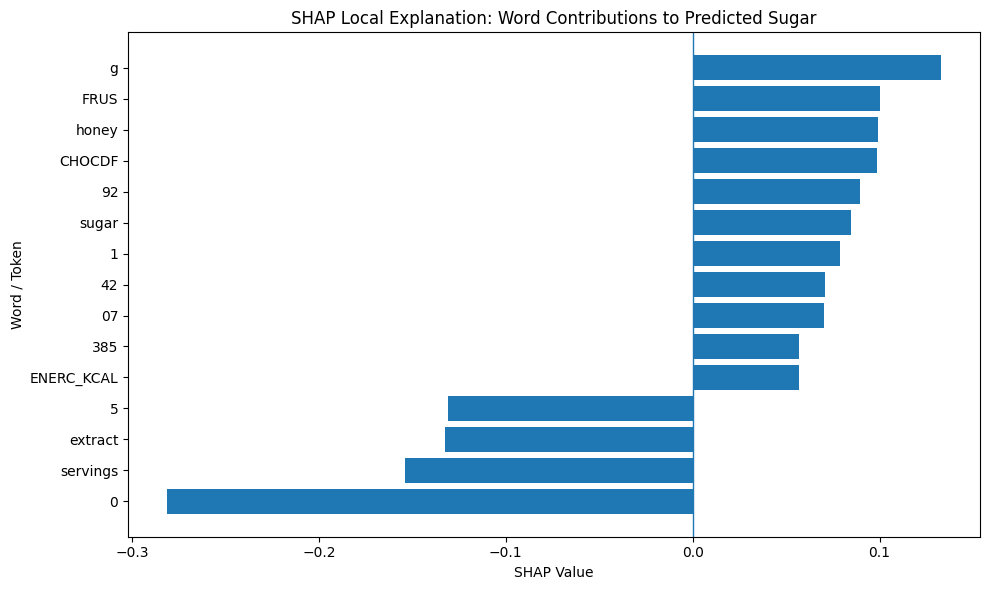

In [39]:
# ============================================================
# STAGE 10.2A — SHAP LOCAL EXPLANATION AND VISUALISATION
#
# Purpose:
# Explain one sugar prediction by identifying which words or
# tokens increase or decrease the predicted sugar value.
#
# Method:
# SHAP estimates how each word/token contributes from the
# model's base prediction to the final predicted sugar value.
#
# Interpretation:
#   Positive SHAP value  = word/token increases predicted sugar
#   Negative SHAP value  = word/token decreases predicted sugar
#   Larger absolute value = stronger influence
#
# Main outputs:
#   1. SHAP text explanation plot
#   2. SHAP word/token contribution table
#   3. SHAP horizontal bar chart
# ============================================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Step 1: Safety checks
# ============================================================

if "predict_sugar_from_texts_xai" not in globals():
    raise NameError(
        "predict_sugar_from_texts_xai is not defined. "
        "Please run the XAI prediction function stage first."
    )

if "xai_display_text" not in globals():
    raise NameError(
        "xai_display_text is not defined. "
        "Please run the XAI sample preparation stage first."
    )

if "XAI_MODEL_NAME" not in globals():
    XAI_MODEL_NAME = "selected_model"


# ============================================================
# Step 2: Define SHAP prediction function
# ============================================================

def shap_predict_readable(texts):
    """
    SHAP prediction function.

    SHAP sends perturbed human-readable text samples to this
    function. The texts are passed directly to the trained
    BERT / DistilBERT prediction function.

    No additional ingredient engineering is applied here.
    """

    texts = [str(t) for t in texts]

    preds = predict_sugar_from_texts_xai(texts)

    return np.array(preds)


# ============================================================
# Step 3: Create SHAP explainer
# ============================================================
# A text masker is used so that SHAP can perturb words/tokens
# and measure their effect on the predicted sugar value.
# ============================================================

shap_masker = shap.maskers.Text(mask_token="[MASK]")

shap_explainer = shap.Explainer(
    shap_predict_readable,
    shap_masker
)


# ============================================================
# Step 4: Generate SHAP explanation
# ============================================================
# max_evals controls runtime.
# If it runs too slow, reduce to 100.
# If the explanation looks unstable, increase to 500.
# ============================================================

shap_values = shap_explainer(
    [xai_display_text],
    max_evals=300
)

shap_prediction = shap_predict_readable([xai_display_text])[0]


# ============================================================
# Step 5: Print SHAP explanation summary
# ============================================================

print("\n========== SHAP LOCAL EXPLANATION SUMMARY ==========")
print("Selected model:", XAI_MODEL_NAME)

print("\nHuman-readable input text:")
print(textwrap.fill(xai_display_text, width=120))

print("\nPredicted sugar per serving (g):", shap_prediction)

print("\nInterpretation:")
print("- Positive SHAP value: word/token increases predicted sugar.")
print("- Negative SHAP value: word/token decreases predicted sugar.")
print("- Larger absolute SHAP value: stronger influence on prediction.")


# ============================================================
# Step 6: Display SHAP text plot
# ============================================================
# This visual plot may look crowded if the tokenizer splits
# words into many small tokens. The table and bar chart below
# are usually clearer for reporting.
# ============================================================

print("\n========== SHAP TEXT PLOT ==========")
shap.plots.text(shap_values[0])


# ============================================================
# Step 7: Convert SHAP explanation into clean table
# ============================================================

shap_tokens = np.array(shap_values[0].data).astype(str)
shap_scores = np.array(shap_values[0].values).squeeze()

# Safety alignment in case token/value length differs
min_len = min(len(shap_tokens), len(shap_scores))
shap_tokens = shap_tokens[:min_len]
shap_scores = shap_scores[:min_len]

shap_result_raw_df = pd.DataFrame({
    "raw_token": shap_tokens,
    "shap_value": shap_scores
})

# Clean token display
def clean_shap_token_display(token):
    """
    Clean SHAP token for readable display.
    This tries to make SHAP output closer to LIME word-level output.
    """

    token = str(token)

    # Remove BERT subword marker
    token = token.replace("##", "")

    # Remove special tokens
    token = token.replace("[CLS]", "")
    token = token.replace("[SEP]", "")
    token = token.replace("[PAD]", "")
    token = token.replace("[MASK]", "")

    # Replace structural separators with spaces
    token = token.replace("|", " ")
    token = token.replace(":", " ")
    token = token.replace(",", " ")
    token = token.replace(";", " ")
    
    # Remove the decimal point
    token = token.replace(".", " ")
    
    # Remove brackets
    token = token.replace("(", " ")
    token = token.replace(")", " ")

    # Standardise spacing
    token = re.sub(r"\s+", " ", token)

    token = token.strip()

    return token


shap_result_raw_df["clean_word_or_token"] = shap_result_raw_df["raw_token"].apply(
    clean_shap_token_display
)


# ------------------------------------------------------------
# Remove empty and meaningless tokens
# ------------------------------------------------------------

shap_result_clean_df = shap_result_raw_df[
    shap_result_raw_df["clean_word_or_token"].astype(str).str.strip() != ""
].copy()

# Remove punctuation-only tokens
shap_result_clean_df = shap_result_clean_df[
    ~shap_result_clean_df["clean_word_or_token"].str.fullmatch(r"[^\w]+")
].copy()


# ------------------------------------------------------------
# Optional: remove standalone decimal fragments
# ------------------------------------------------------------
# This removes tokens such as:
#   0, 5, 92, 385
#
# If you want to keep nutrition values and quantities, set this to False.
# For technical analysis, keeping numbers is okay.
# For report-friendly word explanation, removing them is cleaner.
# ------------------------------------------------------------

REMOVE_STANDALONE_NUMBERS = False

if REMOVE_STANDALONE_NUMBERS:
    shap_result_clean_df = shap_result_clean_df[
        ~shap_result_clean_df["clean_word_or_token"].str.fullmatch(r"\d+(\.\d+)?")
    ].copy()


# ------------------------------------------------------------
# Group repeated cleaned tokens
# ------------------------------------------------------------
# Example:
# If "honey" appears more than once, combine its SHAP values.
# ------------------------------------------------------------

shap_result_df = (
    shap_result_clean_df
    .groupby("clean_word_or_token", as_index=False)
    .agg({
        "shap_value": "sum"
    })
)

shap_result_df["absolute_shap_value"] = shap_result_df["shap_value"].abs()

shap_result_df["direction"] = shap_result_df["shap_value"].apply(
    lambda x: "Increase predicted sugar" if x > 0 else "Decrease predicted sugar"
)

shap_result_df = shap_result_df.sort_values(
    "absolute_shap_value",
    ascending=False
).reset_index(drop=True)


# ============================================================
# Step 8: Display SHAP contribution table
# ============================================================

print("\n========== SHAP WORD / TOKEN CONTRIBUTION TABLE ==========")

display(
    shap_result_df[
        [
            "clean_word_or_token",
            "shap_value",
            "absolute_shap_value",
            "direction"
        ]
    ].head(20)
)


# ============================================================
# Step 9: Plot SHAP bar chart for reporting
# ============================================================

top_n = 15

shap_plot_df = (
    shap_result_df
    .sort_values("absolute_shap_value", ascending=False)
    .head(top_n)
    .copy()
)

# Sort by SHAP value so negative and positive bars are separated
shap_plot_df = shap_plot_df.sort_values("shap_value", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    shap_plot_df["clean_word_or_token"],
    shap_plot_df["shap_value"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("SHAP Value")
plt.ylabel("Word / Token")
plt.title("SHAP Local Explanation: Word Contributions to Predicted Sugar")

plt.tight_layout()
plt.show()

SAVING SHAP RESULTS
Output folder: xai_outputs_shap
✅ SHAP table saved:
xai_outputs_shap/shap_word_token_contribution_table.csv
✅ SHAP summary statement saved:
xai_outputs_shap/shap_summary_statement.txt


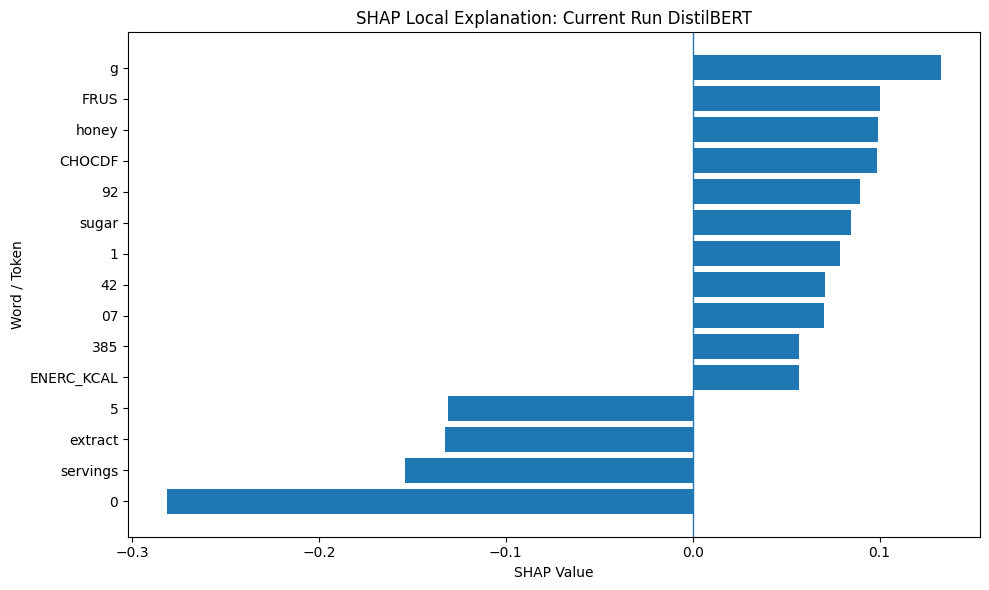

✅ SHAP bar chart saved:
xai_outputs_shap/shap_word_token_contribution_bar_chart.png
✅ SHAP text explanation HTML saved:
xai_outputs_shap/shap_text_explanation.html
✅ Clean SHAP report table saved:
xai_outputs_shap/shap_report_table_clean.csv

========== SAVED SHAP OUTPUT FILES ==========
xai_outputs_shap/shap_text_explanation.html
xai_outputs_shap/shap_summary_statement.txt
xai_outputs_shap/shap_word_token_contribution_bar_chart.png
xai_outputs_shap/shap_word_token_contribution_table.csv
xai_outputs_shap/shap_report_table_clean.csv


In [40]:
# ============================================================
# STAGE 10.2B — SAVE SHAP RESULTS
# ============================================================
#
# Purpose:
# Save SHAP explanation outputs for reporting:
#   1. SHAP summary statement
#   2. SHAP contribution table
#   3. SHAP bar chart
#   4. SHAP text explanation as HTML
#
# Required variables from STAGE 10.2:
#   - shap_result_df
#   - shap_values
#   - xai_display_text
#   - shap_prediction
#   - XAI_MODEL_NAME
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML

# ------------------------------------------------------------
# Step 1: Create output folder
# ------------------------------------------------------------

shap_output_dir = "xai_outputs_shap"
os.makedirs(shap_output_dir, exist_ok=True)

print("=" * 100)
print("SAVING SHAP RESULTS")
print("=" * 100)
print("Output folder:", shap_output_dir)


# ------------------------------------------------------------
# Step 2: Save SHAP contribution table
# ------------------------------------------------------------

shap_table_path = os.path.join(
    shap_output_dir,
    "shap_word_token_contribution_table.csv"
)

shap_result_df.to_csv(shap_table_path, index=False)

print("✅ SHAP table saved:")
print(shap_table_path)


# ------------------------------------------------------------
# Step 3: Create and save SHAP summary statement
# ------------------------------------------------------------

top_positive = (
    shap_result_df[shap_result_df["shap_value"] > 0]
    .sort_values("shap_value", ascending=False)
    .head(5)
)

top_negative = (
    shap_result_df[shap_result_df["shap_value"] < 0]
    .sort_values("shap_value", ascending=True)
    .head(5)
)

top_positive_words = top_positive["clean_word_or_token"].tolist()
top_negative_words = top_negative["clean_word_or_token"].tolist()

summary_text = f"""
SHAP LOCAL EXPLANATION SUMMARY

Selected model:
{XAI_MODEL_NAME}

Input text:
{xai_display_text}

Predicted sugar per serving:
{shap_prediction:.4f} g

Interpretation:
Positive SHAP values indicate that the word or token increases the predicted sugar value.
Negative SHAP values indicate that the word or token decreases the predicted sugar value.
Larger absolute SHAP values indicate stronger influence on the model prediction.

Top positive contributors:
{top_positive_words}

Top negative contributors:
{top_negative_words}

Technical conclusion:
The SHAP explanation shows which parts of the input text most influenced the selected BERT / DistilBERT model prediction. Since the model input contains recipe name, ingredients, serving size, and nutritional values, SHAP may highlight both ingredient-related words and structured nutritional fields. Tokens such as sugar, honey, CHOCDF, FRUS, or ENERC_KCAL are meaningful because they are related to sweetness, carbohydrate content, or sugar-related nutritional information. Some punctuation or numerical fragments may appear because SHAP perturbs text at token or separator boundaries.
""".strip()

shap_summary_path = os.path.join(
    shap_output_dir,
    "shap_summary_statement.txt"
)

with open(shap_summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("✅ SHAP summary statement saved:")
print(shap_summary_path)


# ------------------------------------------------------------
# Step 4: Save SHAP bar chart
# ------------------------------------------------------------

top_n = 15

shap_plot_df = (
    shap_result_df
    .sort_values("absolute_shap_value", ascending=False)
    .head(top_n)
    .copy()
)

shap_plot_df = shap_plot_df.sort_values("shap_value", ascending=True)

shap_bar_chart_path = os.path.join(
    shap_output_dir,
    "shap_word_token_contribution_bar_chart.png"
)

plt.figure(figsize=(10, 6))

plt.barh(
    shap_plot_df["clean_word_or_token"],
    shap_plot_df["shap_value"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("SHAP Value")
plt.ylabel("Word / Token")
plt.title(f"SHAP Local Explanation: {XAI_MODEL_NAME}")

plt.tight_layout()
plt.savefig(shap_bar_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ SHAP bar chart saved:")
print(shap_bar_chart_path)


# ------------------------------------------------------------
# Step 5: Save SHAP text plot as HTML
# ------------------------------------------------------------
# SHAP text plot is interactive / HTML-based in notebooks.
# This saves it as an HTML file.
# ------------------------------------------------------------

shap_text_html_path = os.path.join(
    shap_output_dir,
    "shap_text_explanation.html"
)

try:
    shap_html = shap.plots.text(shap_values[0], display=False)

    with open(shap_text_html_path, "w", encoding="utf-8") as f:
        f.write(str(shap_html))

    print("✅ SHAP text explanation HTML saved:")
    print(shap_text_html_path)

except Exception as e:
    print("⚠️ SHAP text HTML could not be saved automatically.")
    print("Reason:", e)


# ------------------------------------------------------------
# Step 6: Save a clean report table
# ------------------------------------------------------------
# This version keeps only the main report-friendly columns.
# ------------------------------------------------------------

shap_report_table = shap_result_df[
    [
        "clean_word_or_token",
        "shap_value",
        "absolute_shap_value",
        "direction"
    ]
].copy()

shap_report_table_path = os.path.join(
    shap_output_dir,
    "shap_report_table_clean.csv"
)

shap_report_table.to_csv(shap_report_table_path, index=False)

print("✅ Clean SHAP report table saved:")
print(shap_report_table_path)


# ------------------------------------------------------------
# Step 7: Print final saved file list
# ------------------------------------------------------------

print("\n========== SAVED SHAP OUTPUT FILES ==========")
for file_name in os.listdir(shap_output_dir):
    print(os.path.join(shap_output_dir, file_name))

## LIME- Observation, Explain and Summarise
LIME explains a single prediction by slightly perturbing the input text and estimating which words or tokens increase or decrease the model’s predicted value. For this selected sample, the model produced a predicted sugar-per-serving value of **1.3183 g**.

In the LIME result, numerical tokens should be cleaned or interpreted with caution to avoid over-interpreting fragmented values. Tokens such as **“0”, “5”, “385”, and “144”** may not fully represent the original numerical features, as they could be fragments of decimal values or structured nutrition fields. Therefore, these isolated numerical tokens are less suitable for direct standalone interpretation. Instead, the interpretation should focus mainly on meaningful grouped terms such as **“honey”, “sugar”**, and relevant nutrition feature labels.

Overall, the LIME result showed positive contributions from sugar-related tokens such as **“honey”, “sugar”, “vanilla”, and “CHOCDF”**, which is consistent with the prediction task. These terms are directly or indirectly related to sweetness and carbohydrate content, so their positive contribution is technically reasonable. In contrast, grouped tokens such as **“servings”, “ENER_KCAL”, “WATER”, “FAT”, and “PROCNT”** showed negative contributions. The token **“servings”** together with **“5” and “0”**, can be linked back to the original text **“servings: 5.0”**. This is meaningful because serving size has an inverse relationship with sugar per serving when the same recipe is divided into more servings, the sugar-per-serving value is expected to decrease. Therefore, the negative contribution of serving-related tokens is logically aligned with the prediction target.

Overall, the LIME explanation is generally aligned with the project objective. Serving-related tokens such as **“servings”, “5”, and “0”** were identified as decreasing contributors, while sugar-related keywords such as **“honey” and “sugar”** were correctly identified as positive contributors. However, LIME alone is insufficient to fully validate the model’s quantitative reasoning, particularly whether the model truly understands the relationship between ingredient quantity, serving size, and the final sugar-per-serving value. Therefore, further counterfactual or sensitivity testing is recommended to verify whether changes in sugar amount, honey amount, and serving size lead to logically consistent prediction changes.



LIME INPUT TEXT CHECK

Human-readable input text used by LIME:
recipe_name: Test cook | ingredients: 200 g sugar, 42 g honey, 1 cup milk,1 tsp vanilla extract | servings: 5.0 |
STARCH: 2.01 | FIBTG: 3.98 | WATER: 144.97 |FAT: 28.83 | PROCNT: 18.07 | CHOCDF: 16.64 | ENERC_KCAL: 385.41 | SUCS: 0.73
| GLUS: 0.92 |FRUS: 0.96 | LACS: 0.79 | MALS: 0.05 | GALS: 0.12 | CHOLE: 0.22 | ASH: 3.65 | CAFFN: 0.01

========== LIME LOCAL EXPLANATION SUMMARY ==========
Selected model: Current Run DistilBERT

Human-readable input text:
recipe_name: Test cook | ingredients: 200 g sugar, 42 g honey, 1 cup milk,1 tsp vanilla extract | servings: 5.0 |
STARCH: 2.01 | FIBTG: 3.98 | WATER: 144.97 |FAT: 28.83 | PROCNT: 18.07 | CHOCDF: 16.64 | ENERC_KCAL: 385.41 | SUCS: 0.73
| GLUS: 0.92 |FRUS: 0.96 | LACS: 0.79 | MALS: 0.05 | GALS: 0.12 | CHOLE: 0.22 | ASH: 3.65 | CAFFN: 0.01

Predicted sugar per serving (g): 1.3182974

Interpretation:
- Positive LIME weight: word/token increases predicted sugar.
- Negative LIME

,word_or_token,lime_weight,absolute_weight,direction
0,0,-1.196093,1.196093,Decrease predicted sugar
1,servings,-0.483496,0.483496,Decrease predicted sugar
2,5,-0.399227,0.399227,Decrease predicted sugar
3,ENERC_KCAL,-0.343786,0.343786,Decrease predicted sugar
4,honey,0.288362,0.288362,Increase predicted sugar
5,385,0.269784,0.269784,Increase predicted sugar
6,sugar,0.227297,0.227297,Increase predicted sugar
7,144,0.169411,0.169411,Increase predicted sugar
8,vanilla,0.146428,0.146428,Increase predicted sugar
9,3,-0.130655,0.130655,Decrease predicted sugar


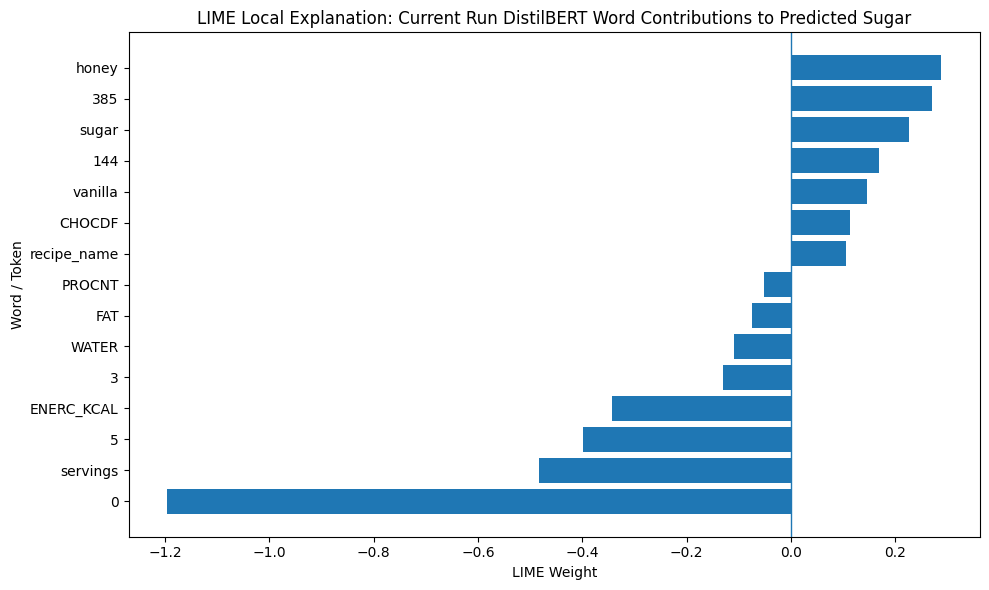

In [35]:
# ============================================================
# STAGE 10.3A — LIME LOCAL EXPLANATION AND VISUALISATION
#
# Purpose:
# Explain one sugar prediction by identifying which words or
# tokens increase or decrease the predicted sugar value.
#
# Note:
# LimeTextExplainer in this environment does not support
# mode="regression". Therefore, the regression prediction is
# returned as a single-output array with shape (n_samples, 1),
# and LIME explains label 0.
#
# Interpretation:
#   Positive LIME weight  = word/token increases predicted sugar
#   Negative LIME weight  = word/token decreases predicted sugar
#   Larger absolute value = stronger influence
# ============================================================

from lime.lime_text import LimeTextExplainer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap


# ============================================================
# Step 1: Safety checks
# ============================================================

if "predict_sugar_from_texts_xai" not in globals():
    raise NameError(
        "predict_sugar_from_texts_xai is not defined. "
        "Please run STAGE 10.1B — XAI prediction function first."
    )

if "xai_display_text" not in globals():
    raise NameError(
        "xai_display_text is not defined. "
        "Please run the XAI sample preparation stage first."
    )

if "XAI_MODEL_NAME" not in globals():
    XAI_MODEL_NAME = "selected_model"


# ============================================================
# Step 2: Check human-readable input text
# ============================================================

print("=" * 100)
print("LIME INPUT TEXT CHECK")
print("=" * 100)

print("\nHuman-readable input text used by LIME:")
print(textwrap.fill(str(xai_display_text), width=120))


# ============================================================
# Step 3: Define LIME prediction function
# ============================================================

def lime_predict(texts):
    """
    LIME prediction function.

    LIME will generate many perturbed versions of the input text.
    This function sends those texts to the selected BERT / DistilBERT
    model and returns predicted sugar values.

    Required output shape for LimeTextExplainer:
        (number_of_samples, 1)
    """

    preds = predict_sugar_from_texts_xai(list(texts))

    return np.array(preds).reshape(-1, 1)


# ============================================================
# Step 4: Create LIME explainer
# ============================================================
# Important:
# Do NOT use mode="regression" because this LimeTextExplainer
# version does not support it.
# ============================================================

lime_explainer = LimeTextExplainer(
    class_names=["predicted_sugar_per_serving_g"],
    bow=True,
    split_expression=r"\W+",
    random_state=42
)


# ============================================================
# Step 5: Run LIME explanation
# ============================================================

lime_exp = lime_explainer.explain_instance(
    xai_display_text,
    lime_predict,
    labels=(0,),
    num_features=15,
    num_samples=1000
)


# ============================================================
# Step 6: Convert LIME result into clean table
# ============================================================

lime_result_df = pd.DataFrame(
    lime_exp.as_list(label=0),
    columns=["word_or_token", "lime_weight"]
)

lime_result_df["absolute_weight"] = lime_result_df["lime_weight"].abs()

lime_result_df["direction"] = lime_result_df["lime_weight"].apply(
    lambda x: "Increase predicted sugar" if x > 0 else "Decrease predicted sugar"
)

lime_result_df = lime_result_df.sort_values(
    "absolute_weight",
    ascending=False
).reset_index(drop=True)


# ============================================================
# Step 7: Print summary
# ============================================================

lime_prediction = predict_sugar_from_texts_xai([xai_display_text])[0]

print("\n========== LIME LOCAL EXPLANATION SUMMARY ==========")
print("Selected model:", XAI_MODEL_NAME)

print("\nHuman-readable input text:")
print(textwrap.fill(str(xai_display_text), width=120))

print("\nPredicted sugar per serving (g):", lime_prediction)

print("\nInterpretation:")
print("- Positive LIME weight: word/token increases predicted sugar.")
print("- Negative LIME weight: word/token decreases predicted sugar.")
print("- Larger absolute weight: stronger influence on prediction.")


# ============================================================
# Step 8: Display LIME result table
# ============================================================

print("\n========== LIME WORD / TOKEN CONTRIBUTION TABLE ==========")

display(
    lime_result_df[
        [
            "word_or_token",
            "lime_weight",
            "absolute_weight",
            "direction"
        ]
    ]
)


# ============================================================
# Step 9: Plot LIME bar chart
# ============================================================

top_n = 15

lime_plot_df = (
    lime_result_df
    .sort_values("absolute_weight", ascending=False)
    .head(top_n)
    .copy()
)

lime_plot_df = lime_plot_df.sort_values("lime_weight", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    lime_plot_df["word_or_token"],
    lime_plot_df["lime_weight"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("LIME Weight")
plt.ylabel("Word / Token")
plt.title(f"LIME Local Explanation: {XAI_MODEL_NAME} Word Contributions to Predicted Sugar")

plt.tight_layout()
plt.show()

LIME output folder created: xai_lime_results
Detected LIME explanation object: lime_exp
Available LIME local explanation labels:
dict_keys([0])
Using LIME label: 0


,Feature / Token,LIME Contribution,Effect Direction,Absolute Importance
0,0,-1.196093,Decrease Prediction,1.196093
1,servings,-0.483496,Decrease Prediction,0.483496
2,5,-0.399227,Decrease Prediction,0.399227
3,ENERC_KCAL,-0.343786,Decrease Prediction,0.343786
4,honey,0.288362,Increase Prediction,0.288362
5,385,0.269784,Increase Prediction,0.269784
6,sugar,0.227297,Increase Prediction,0.227297
7,144,0.169411,Increase Prediction,0.169411
8,vanilla,0.146428,Increase Prediction,0.146428
9,3,-0.130655,Decrease Prediction,0.130655


Saved LIME table:
xai_lime_results/lime_explanation_table.csv
xai_lime_results/lime_explanation_table.xlsx
Saved LIME HTML explanation:
xai_lime_results/lime_explanation.html
Saved LIME summary:
xai_lime_results/lime_summary.txt


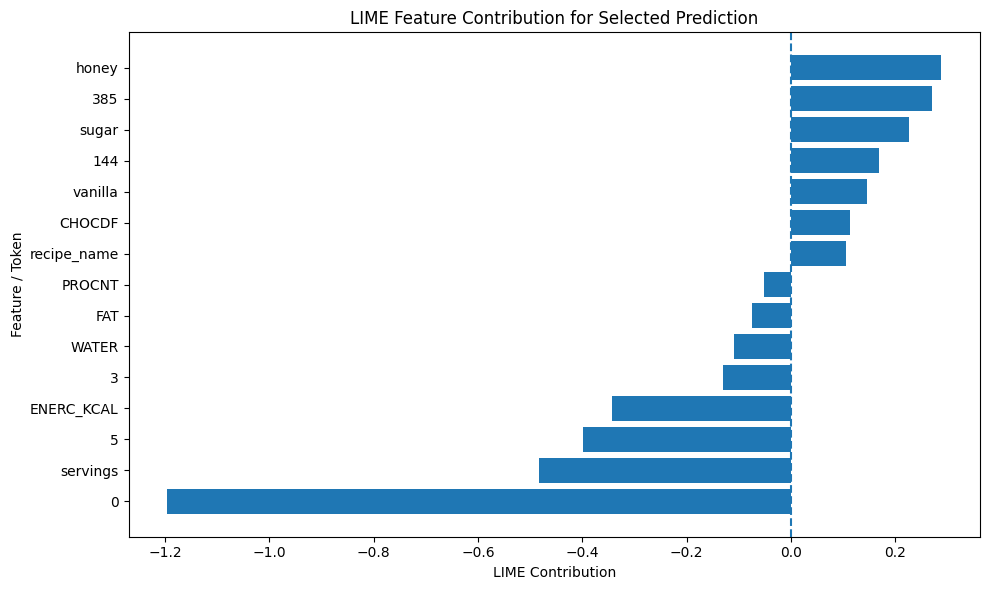

Saved LIME bar chart:
xai_lime_results/lime_contribution_bar_chart.png

All LIME results saved successfully:
1. CSV table   : xai_lime_results/lime_explanation_table.csv
2. Excel table : xai_lime_results/lime_explanation_table.xlsx
3. HTML file   : xai_lime_results/lime_explanation.html
4. Summary txt : xai_lime_results/lime_summary.txt
5. PNG chart   : xai_lime_results/lime_contribution_bar_chart.png


In [43]:
# ============================================================
# STAGE 10.3B — SAVE LIME EXPLANATION RESULTS
#
# This stage saves the LIME explanation result from STAGE 10.3.
# It automatically detects the LIME explanation object and avoids
# LIME label mismatch errors such as KeyError: 1.
#
# Saved outputs:
#   1. LIME explanation table (.csv)
#   2. LIME explanation table (.xlsx)
#   3. LIME explanation HTML (.html)
#   4. LIME explanation summary (.txt)
#   5. LIME contribution bar chart (.png)
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Create output folder
# ------------------------------------------------------------

LIME_OUTPUT_DIR = "xai_lime_results"
os.makedirs(LIME_OUTPUT_DIR, exist_ok=True)

print(f"LIME output folder created: {LIME_OUTPUT_DIR}")


# ------------------------------------------------------------
# 2. Automatically detect LIME explanation object
# ------------------------------------------------------------

lime_explanation = None

possible_lime_names = ["lime_exp", "exp", "explanation", "lime_explanation"]

for name in possible_lime_names:
    if name in globals():
        lime_explanation = globals()[name]
        print(f"Detected LIME explanation object: {name}")
        break

if lime_explanation is None:
    raise NameError(
        "No LIME explanation object found. "
        "Please run STAGE 10.3 first and create lime_exp."
    )


# ------------------------------------------------------------
# 3. Convert LIME result to table safely
# ------------------------------------------------------------

print("Available LIME local explanation labels:")
print(lime_explanation.local_exp.keys())

available_labels = list(lime_explanation.local_exp.keys())

if len(available_labels) == 0:
    raise ValueError("No LIME explanation labels found in lime_explanation.local_exp.")

lime_label = available_labels[0]

print(f"Using LIME label: {lime_label}")

lime_result = lime_explanation.as_list(label=lime_label)

lime_df = pd.DataFrame(
    lime_result,
    columns=["Feature / Token", "LIME Contribution"]
)

lime_df["Effect Direction"] = lime_df["LIME Contribution"].apply(
    lambda x: "Increase Prediction" if x > 0 else "Decrease Prediction"
)

lime_df["Absolute Importance"] = lime_df["LIME Contribution"].abs()

lime_df = lime_df.sort_values(
    by="Absolute Importance",
    ascending=False
).reset_index(drop=True)

display(lime_df)


# ------------------------------------------------------------
# 4. Save table as CSV and Excel
# ------------------------------------------------------------

lime_csv_path = os.path.join(LIME_OUTPUT_DIR, "lime_explanation_table.csv")
lime_excel_path = os.path.join(LIME_OUTPUT_DIR, "lime_explanation_table.xlsx")

lime_df.to_csv(lime_csv_path, index=False)
lime_df.to_excel(lime_excel_path, index=False)

print("Saved LIME table:")
print(lime_csv_path)
print(lime_excel_path)


# ------------------------------------------------------------
# 5. Save LIME explanation as HTML
# ------------------------------------------------------------

lime_html_path = os.path.join(LIME_OUTPUT_DIR, "lime_explanation.html")

lime_explanation.save_to_file(lime_html_path)

print("Saved LIME HTML explanation:")
print(lime_html_path)


# ------------------------------------------------------------
# 6. Save LIME summary statement
# ------------------------------------------------------------

top_positive = lime_df[lime_df["LIME Contribution"] > 0].head(3)
top_negative = lime_df[lime_df["LIME Contribution"] < 0].head(3)

summary_text = "LIME Explanation Summary\n"
summary_text += "=" * 40 + "\n\n"

summary_text += "LIME was used to explain the model prediction for one selected test sample.\n"
summary_text += "Positive contribution values indicate tokens or features that increased the predicted sugar-per-serving value.\n"
summary_text += "Negative contribution values indicate tokens or features that reduced the predicted sugar-per-serving value.\n\n"

summary_text += "Top features increasing the prediction:\n"
if len(top_positive) > 0:
    for _, row in top_positive.iterrows():
        summary_text += f"- {row['Feature / Token']}: {row['LIME Contribution']:.4f}\n"
else:
    summary_text += "- No positive contribution found.\n"

summary_text += "\nTop features decreasing the prediction:\n"
if len(top_negative) > 0:
    for _, row in top_negative.iterrows():
        summary_text += f"- {row['Feature / Token']}: {row['LIME Contribution']:.4f}\n"
else:
    summary_text += "- No negative contribution found.\n"

lime_summary_path = os.path.join(LIME_OUTPUT_DIR, "lime_summary.txt")

with open(lime_summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Saved LIME summary:")
print(lime_summary_path)


# ------------------------------------------------------------
# 7. Save LIME contribution bar chart
# ------------------------------------------------------------

plot_df = lime_df.sort_values("LIME Contribution", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Feature / Token"],
    plot_df["LIME Contribution"]
)

plt.axvline(0, linestyle="--")
plt.xlabel("LIME Contribution")
plt.ylabel("Feature / Token")
plt.title("LIME Feature Contribution for Selected Prediction")
plt.tight_layout()

lime_plot_path = os.path.join(LIME_OUTPUT_DIR, "lime_contribution_bar_chart.png")

plt.savefig(lime_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved LIME bar chart:")
print(lime_plot_path)


# ------------------------------------------------------------
# 8. Confirm saved files
# ------------------------------------------------------------

print("\nAll LIME results saved successfully:")
print(f"1. CSV table   : {lime_csv_path}")
print(f"2. Excel table : {lime_excel_path}")
print(f"3. HTML file   : {lime_html_path}")
print(f"4. Summary txt : {lime_summary_path}")
print(f"5. PNG chart   : {lime_plot_path}")

## Captum Integrated Gradients- Observation, Explain and Summarise
The Captum Integrated Gradients explanation illustrates how individual tokens in the selected recipe input contributed to the model’s predicted sugar-per-serving value. For this sample, the model predicted a sugar-per-serving value of approximately **2.74 g**.

Some alphabetic tokens, such as **“f”, “al”, “s”, “fr”, and “us”**, appeared because the BERT tokenizer decomposed technical nutrition abbreviations into smaller subword fragments. These alphabetic fragments should not be interpreted as meaningful standalone words, as they likely originate from abbreviated nutrition feature names rather than normal recipe terms. Similarly, numerical values may also be split into separate fragments during tokenization or preprocessing. Therefore, the interpretation should focus mainly on meaningful grouped tokens such as **“honey”, “sugar”, “serving”, “water”, and “fat”**.

Looking further into the meaningful grouped tokens, **“honey” and “sugar”** are expected to increase the predicted sugar-per-serving value because they are directly related to sweetness and sugar content. On the other hand, tokens such as **“serving”, “water”, “ingredients”, and “fat”** contributed negatively. Among these, **“serving”** showed the strongest negative contribution, which is technically reasonable because the target variable is sugar per serving. A higher serving count is expected to reduce the sugar-per-serving value when the total recipe quantity remains unchanged. The negative contribution of **“water”** is also understandable, as higher water content may dilute the sugar concentration. However, the negative contributions of **“ingredients” and “fat”** are less directly explainable and should be interpreted with caution.

Overall, the Captum result is generally aligned with the prediction objective. The meaningful grouped tokens identified by Captum indicate that the model considers relevant recipe and nutrition information when predicting sugar per serving. However, fragmented alphabetic and numerical tokens should not be over-interpreted and the explanation should prioritise domain-relevant grouped tokens.

========== CAPTUM SAMPLE TEXT CHECK ==========
Human-readable text:
recipe_name: Test cook | ingredients: 200 g sugar, 42 g honey, 1 cup milk,1 tsp vanilla extract | servings: 5.0 | STARCH: 2.01 | FIBTG: 3.98 | WATER: 144.97 |FAT: 28.83 | PROCNT: 18.07 | CHOCDF: 16.64 | ENERC_KCAL: 385.41 | SUCS: 0.73 | GLUS: 0.92 |FRUS: 0.96 | LACS: 0.79 | MALS: 0.05 | GALS: 0.12 | CHOLE: 0.22 | ASH: 3.65 | CAFFN: 0.01

✅ Captum Integrated Gradients generated successfully.
Selected model: Current Run DistilBERT
Raw model output: 1.3182973861694336
Predicted sugar per serving (g): 2.7370531990628275
Convergence delta: [-0.01401639]

========== CLEANED GROUPED CAPTUM TOKEN CONTRIBUTIONS ==========


,group_token,integrated_gradient_score,absolute_score,importance_percent,direction
0,0,-0.710761,0.710761,25.286552,Decrease predicted sugar
1,honey,0.273712,0.273712,9.737792,Increase predicted sugar
2,sugar,0.196646,0.196646,6.996025,Increase predicted sugar
3,16,-0.154501,0.154501,5.496647,Decrease predicted sugar
4,serving,-0.128468,0.128468,4.570480,Decrease predicted sugar
5,g,-0.001125,0.114742,4.082136,Decrease predicted sugar
6,3,-0.090689,0.090689,3.226413,Decrease predicted sugar
7,s,-0.063276,0.065584,2.333261,Decrease predicted sugar
8,f,0.059644,0.062933,2.238963,Increase predicted sugar
9,al,-0.052738,0.052738,1.876247,Decrease predicted sugar


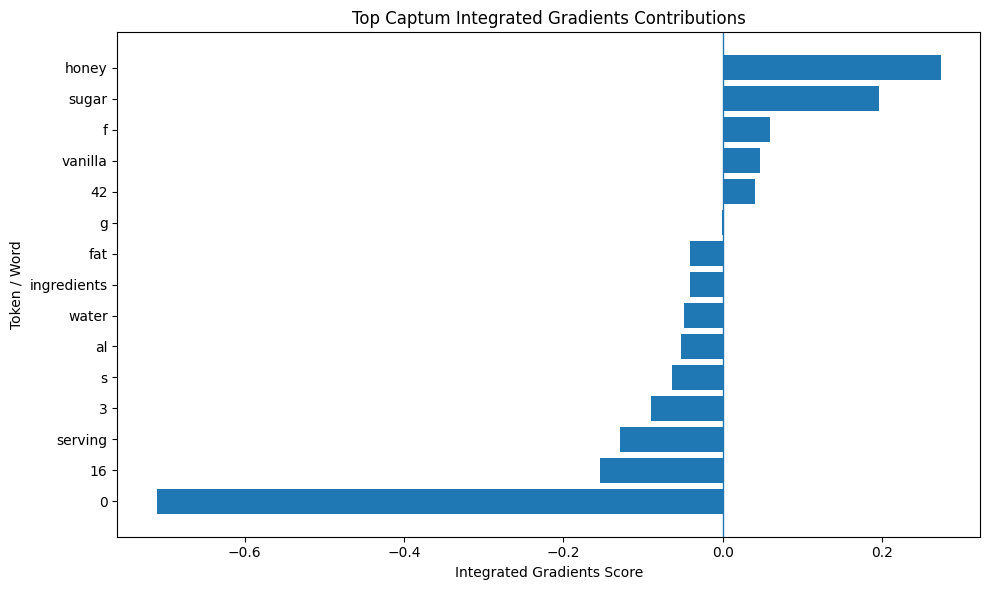

In [44]:
# ============================================================
# STAGE 10.4A — CAPTUM INTEGRATED GRADIENTS + CLEANED OUTPUT + BAR CHART
#
# Purpose:
# Run Captum Integrated Gradients on the same sample used by
# SHAP and LIME, then produce:
#
#   1. Captum sample text check
#   2. Cleaned grouped Captum token contribution table
#   3. Captum bar chart
#
# Main output dataframe:
#   captum_grouped_clean
#
# Interpretation:
#   Positive score = token increases predicted sugar
#   Negative score = token decreases predicted sugar
#   Larger absolute score = stronger contribution
# ============================================================

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from captum.attr import LayerIntegratedGradients


# ============================================================
# Step 1: Safety checks
# ============================================================

if "xai_display_text" not in globals():
    raise NameError(
        "xai_display_text is not defined. Please run the XAI sample preparation stage first."
    )

if "xai_model" not in globals():
    raise NameError(
        "xai_model is not defined. Please run the XAI model loading stage first."
    )

if "xai_tokenizer" not in globals():
    raise NameError(
        "xai_tokenizer is not defined. Please run the XAI model loading stage first."
    )

if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if "USE_LOG_TARGET" not in globals():
    USE_LOG_TARGET = True


# ============================================================
# Step 2: Use same text source as SHAP and LIME
# ============================================================

captum_display_text = xai_display_text

# The model was trained using cleaned ingredient text.
# Therefore, Captum should explain the cleaned model input,
# but we still print the human-readable text for reference.

print("========== CAPTUM SAMPLE TEXT CHECK ==========")
print("Human-readable text:")
print(captum_display_text)

# ============================================================
# Step 3: Detect embedding layer
# ============================================================

def get_embedding_layer(model):
    """
    Return the embedding layer for DistilBERT or BERT.
    """
    if hasattr(model, "distilbert"):
        return model.distilbert.embeddings
    elif hasattr(model, "bert"):
        return model.bert.embeddings
    else:
        raise ValueError("Unsupported model type. Cannot find embedding layer.")


embedding_layer = get_embedding_layer(xai_model)


# ============================================================
# Step 4: Define Captum forward function
# ============================================================

def captum_forward_func(input_ids, attention_mask):
    """
    Forward function required by Captum.

    Output:
        Model regression output in training scale.
        If USE_LOG_TARGET = True, this output is still log-scale.
    """
    outputs = xai_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )
    return outputs.logits.squeeze(-1)


# ============================================================
# Step 5: Tokenize cleaned sample text
# ============================================================

encoded = xai_tokenizer(
    captum_display_text,
    padding="max_length",
    truncation=True,
    max_length=192,
    return_tensors="pt"
)

input_ids = encoded["input_ids"].to(device)
attention_mask = encoded["attention_mask"].to(device)


# ============================================================
# Step 6: Create baseline input
# ============================================================

pad_token_id = xai_tokenizer.pad_token_id
baseline_ids = torch.full_like(input_ids, pad_token_id).to(device)

# Keep CLS token the same
if xai_tokenizer.cls_token_id is not None:
    baseline_ids[:, 0] = xai_tokenizer.cls_token_id

# Keep SEP token the same
if xai_tokenizer.sep_token_id is not None:
    sep_positions = (input_ids == xai_tokenizer.sep_token_id).nonzero(as_tuple=False)
    for pos in sep_positions:
        baseline_ids[pos[0], pos[1]] = xai_tokenizer.sep_token_id


# ============================================================
# Step 7: Run Layer Integrated Gradients
# ============================================================

xai_model.to(device)
xai_model.eval()

lig = LayerIntegratedGradients(
    captum_forward_func,
    embedding_layer
)

attributions, delta = lig.attribute(
    inputs=input_ids,
    baselines=baseline_ids,
    additional_forward_args=(attention_mask,),
    return_convergence_delta=True,
    n_steps=30
)


# ============================================================
# Step 8: Extract raw token-level Captum scores
# ============================================================

token_attributions = attributions.sum(dim=-1).squeeze(0)
token_attributions = token_attributions.detach().cpu().numpy()

tokens = xai_tokenizer.convert_ids_to_tokens(
    input_ids.squeeze(0).detach().cpu().numpy()
)

attention_mask_np = attention_mask.squeeze(0).detach().cpu().numpy()

captum_rows = []

for token, score, mask_value in zip(tokens, token_attributions, attention_mask_np):

    if mask_value == 0:
        continue

    if token in [
        xai_tokenizer.cls_token,
        xai_tokenizer.sep_token,
        xai_tokenizer.pad_token
    ]:
        continue

    captum_rows.append({
        "token": token,
        "integrated_gradient_score": float(score)
    })

captum_df = pd.DataFrame(captum_rows)


# ============================================================
# Step 9: Clean and group repeated Captum tokens
# ============================================================

def clean_token_for_grouping(token):
    """
    Clean BERT / DistilBERT token fragments for reporting.
    """
    token = str(token)
    token = token.replace("##", "")
    token = token.replace("_", " ")
    token = token.strip()
    return token


captum_df["group_token"] = captum_df["token"].apply(clean_token_for_grouping)

# Remove empty tokens
captum_df = captum_df[
    captum_df["group_token"].astype(str).str.strip() != ""
].copy()

# Remove punctuation-only tokens such as "," or "-"
captum_df = captum_df[
    ~captum_df["group_token"].str.fullmatch(r"[^\w]+")
].copy()

# Remove common tokenizer fragments
remove_tokens = {
    "q", "p", "ty", "ts", "_", "-", ",", ".", "(", ")", "[", "]",
    "|", ":", ";", "'", '"'
}

captum_df = captum_df[
    ~captum_df["group_token"].isin(remove_tokens)
].copy()

# Ensure numeric score
captum_df["integrated_gradient_score"] = pd.to_numeric(
    captum_df["integrated_gradient_score"],
    errors="coerce"
)

captum_df = captum_df.dropna(subset=["integrated_gradient_score"]).copy()

captum_df["absolute_score"] = captum_df["integrated_gradient_score"].abs()

# Group repeated tokens
captum_grouped_clean = (
    captum_df
    .groupby("group_token", as_index=False)
    .agg({
        "integrated_gradient_score": "sum",
        "absolute_score": "sum"
    })
)

captum_grouped_clean["direction"] = captum_grouped_clean[
    "integrated_gradient_score"
].apply(
    lambda x: "Increase predicted sugar" if x > 0 else "Decrease predicted sugar"
)

# Importance percentage
total_abs_score = captum_grouped_clean["absolute_score"].sum()

if total_abs_score > 0:
    captum_grouped_clean["importance_percent"] = (
        captum_grouped_clean["absolute_score"] / total_abs_score * 100
    )
else:
    captum_grouped_clean["importance_percent"] = 0

captum_grouped_clean = captum_grouped_clean.sort_values(
    "absolute_score",
    ascending=False
).reset_index(drop=True)


# ============================================================
# Step 10: Prediction value for reference
# ============================================================

with torch.no_grad():
    outputs = xai_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    raw_prediction = outputs.logits.squeeze().item()

if USE_LOG_TARGET:
    predicted_sugar = np.expm1(raw_prediction)
else:
    predicted_sugar = raw_prediction

predicted_sugar = max(predicted_sugar, 0)


print("\n✅ Captum Integrated Gradients generated successfully.")
print("Selected model:", XAI_MODEL_NAME if "XAI_MODEL_NAME" in globals() else "XAI model")
print("Raw model output:", raw_prediction)
print("Predicted sugar per serving (g):", predicted_sugar)
print("Convergence delta:", delta.detach().cpu().numpy())


# ============================================================
# Step 11: Display cleaned grouped Captum output
# ============================================================

print("\n========== CLEANED GROUPED CAPTUM TOKEN CONTRIBUTIONS ==========")

display(
    captum_grouped_clean[
        [
            "group_token",
            "integrated_gradient_score",
            "absolute_score",
            "importance_percent",
            "direction"
        ]
    ].head(20)
)


# ============================================================
# Step 12: Captum bar chart using captum_grouped_clean
# ============================================================

top_n = 15

plot_df = (
    captum_grouped_clean
    .sort_values("absolute_score", ascending=False)
    .head(top_n)
    .copy()
)

# Sort for horizontal bar chart readability
plot_df = plot_df.sort_values("integrated_gradient_score", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["group_token"],
    plot_df["integrated_gradient_score"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Integrated Gradients Score")
plt.ylabel("Token / Word")
plt.title("Top Captum Integrated Gradients Contributions")

plt.tight_layout()
plt.show()

Captum output folder created: xai_captum_results
Detected Captum attribution variable: attributions
Detected Captum token variable: tokens


,Original Token,Clean Token,Captum Attribution,Effect Direction,Absolute Importance
0,honey,honey,0.273712,Increase Prediction,0.273712
1,sugar,sugar,0.196646,Increase Prediction,0.196646
2,16,16,-0.154501,Decrease Prediction,0.154501
3,0,0,-0.129554,Decrease Prediction,0.129554
4,serving,serving,-0.128468,Decrease Prediction,0.128468
...,...,...,...,...,...
88,en,en,0.001130,Increase Prediction,0.001130
89,##le,le,0.000442,Increase Prediction,0.000442
90,##nt,nt,0.000369,Increase Prediction,0.000369
91,caf,caf,0.000349,Increase Prediction,0.000349


Saved Captum table:
xai_captum_results/captum_attribution_table.csv
xai_captum_results/captum_attribution_table.xlsx
Saved raw Captum attribution tensor:
xai_captum_results/captum_raw_attributions.pt
Saved Captum summary:
xai_captum_results/captum_summary.txt


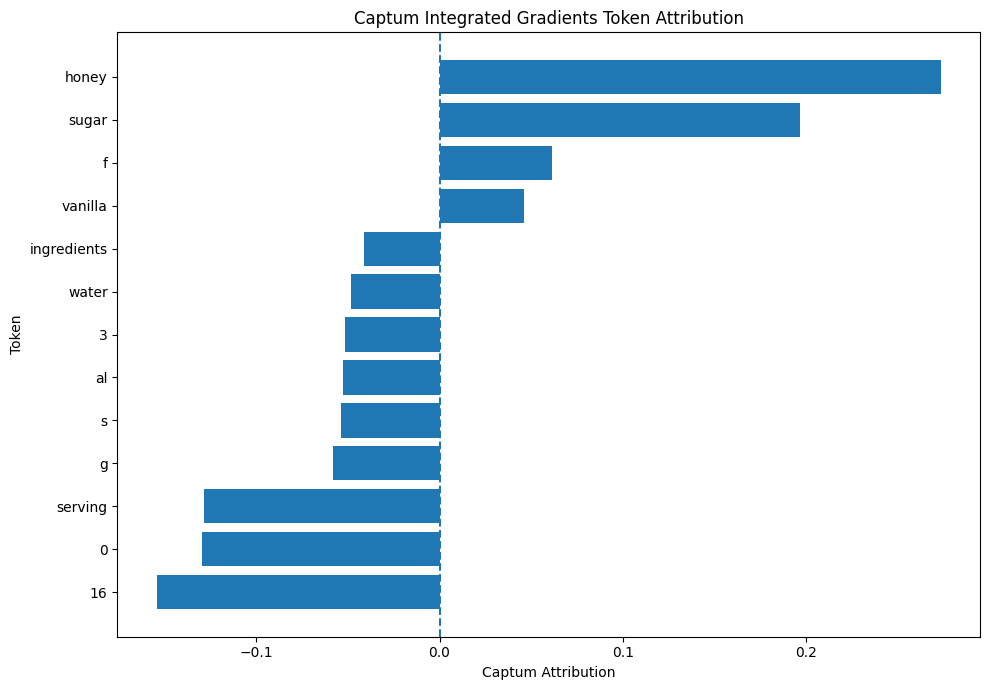

Saved Captum bar chart:
xai_captum_results/captum_attribution_bar_chart.png

All Captum results saved successfully:
1. CSV table        : xai_captum_results/captum_attribution_table.csv
2. Excel table      : xai_captum_results/captum_attribution_table.xlsx
3. Summary txt      : xai_captum_results/captum_summary.txt
4. PNG chart        : xai_captum_results/captum_attribution_bar_chart.png
5. Raw attribution  : xai_captum_results/captum_raw_attributions.pt


In [46]:
# ============================================================
# STAGE 10.4B — SAVE CAPTUM INTEGRATED GRADIENTS RESULTS
#
# This stage saves the Captum Integrated Gradients explanation
# result for reporting and future reference.
#
# Saved outputs:
#   1. Captum attribution table (.csv)
#   2. Captum attribution table (.xlsx)
#   3. Captum explanation summary (.txt)
#   4. Captum attribution bar chart (.png)
#   5. Raw Captum attribution tensor (.pt)
# ============================================================

import os
import re
import torch
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Create output folder
# ------------------------------------------------------------

CAPTUM_OUTPUT_DIR = "xai_captum_results"
os.makedirs(CAPTUM_OUTPUT_DIR, exist_ok=True)

print(f"Captum output folder created: {CAPTUM_OUTPUT_DIR}")


# ------------------------------------------------------------
# 2. Helper function: clean token display
# ------------------------------------------------------------

def clean_captum_token_display(token):
    """
    Clean token display for Captum result table.

    This makes BERT-style tokens easier to read.
    Example:
        ##ing -> ing
        5.   -> 5
        .0   -> 0
    """

    token = str(token)

    # Remove BERT subword marker
    token = token.replace("##", "")

    # Remove special tokens
    token = token.replace("[CLS]", "")
    token = token.replace("[SEP]", "")
    token = token.replace("[PAD]", "")
    token = token.replace("[MASK]", "")

    # Replace separators
    token = token.replace("|", " ")
    token = token.replace(":", " ")
    token = token.replace(",", " ")
    token = token.replace(";", " ")
    token = token.replace(".", " ")

    # Remove brackets
    token = token.replace("(", " ")
    token = token.replace(")", " ")

    # Standardise spacing
    token = re.sub(r"\s+", " ", token)

    return token.strip()


# ------------------------------------------------------------
# 3. Automatically detect Captum variables
# ------------------------------------------------------------

# Expected possible variable names from previous Captum stage
possible_attr_names = [
    "attributions",
    "captum_attributions",
    "ig_attributions",
    "token_attributions",
    "attr"
]

possible_token_names = [
    "tokens",
    "captum_tokens",
    "input_tokens",
    "token_list",
    "all_tokens"
]

captum_attr = None
captum_tokens = None

for name in possible_attr_names:
    if name in globals():
        captum_attr = globals()[name]
        print(f"Detected Captum attribution variable: {name}")
        break

for name in possible_token_names:
    if name in globals():
        captum_tokens = globals()[name]
        print(f"Detected Captum token variable: {name}")
        break

if captum_attr is None:
    raise NameError(
        "No Captum attribution variable found.\n\n"
        "Please make sure your Captum stage has one of these variable names:\n"
        f"{possible_attr_names}\n\n"
        "Example:\n"
        "attributions, delta = integrated_gradients.attribute(...)\n"
    )

if captum_tokens is None:
    raise NameError(
        "No Captum token list found.\n\n"
        "Please make sure your Captum stage has one of these variable names:\n"
        f"{possible_token_names}\n\n"
        "Example:\n"
        "tokens = tokenizer.convert_ids_to_tokens(input_ids[0])\n"
    )


# ------------------------------------------------------------
# 4. Convert attribution tensor to token-level scores
# ------------------------------------------------------------

# Convert attribution to tensor if needed
if not torch.is_tensor(captum_attr):
    captum_attr = torch.tensor(captum_attr)

# Remove batch dimension if available
attr_tensor = captum_attr.detach().cpu()

if attr_tensor.ndim == 3:
    # Shape usually: [batch, sequence_length, embedding_dim]
    token_scores = attr_tensor.sum(dim=-1).squeeze(0)

elif attr_tensor.ndim == 2:
    # Shape could be: [sequence_length, embedding_dim]
    token_scores = attr_tensor.sum(dim=-1)

elif attr_tensor.ndim == 1:
    # Already token-level attribution
    token_scores = attr_tensor

else:
    raise ValueError(f"Unexpected attribution tensor shape: {attr_tensor.shape}")

token_scores = token_scores.numpy()


# ------------------------------------------------------------
# 5. Align tokens and attribution scores
# ------------------------------------------------------------

captum_tokens = list(captum_tokens)

min_len = min(len(captum_tokens), len(token_scores))

captum_tokens = captum_tokens[:min_len]
token_scores = token_scores[:min_len]

captum_df = pd.DataFrame({
    "Original Token": captum_tokens,
    "Clean Token": [clean_captum_token_display(t) for t in captum_tokens],
    "Captum Attribution": token_scores
})

# Remove empty special-token rows after cleaning
captum_df = captum_df[captum_df["Clean Token"] != ""].copy()

captum_df["Effect Direction"] = captum_df["Captum Attribution"].apply(
    lambda x: "Increase Prediction" if x > 0 else "Decrease Prediction"
)

captum_df["Absolute Importance"] = captum_df["Captum Attribution"].abs()

captum_df = captum_df.sort_values(
    by="Absolute Importance",
    ascending=False
).reset_index(drop=True)

display(captum_df)


# ------------------------------------------------------------
# 6. Save Captum table as CSV and Excel
# ------------------------------------------------------------

captum_csv_path = os.path.join(CAPTUM_OUTPUT_DIR, "captum_attribution_table.csv")
captum_excel_path = os.path.join(CAPTUM_OUTPUT_DIR, "captum_attribution_table.xlsx")

captum_df.to_csv(captum_csv_path, index=False)
captum_df.to_excel(captum_excel_path, index=False)

print("Saved Captum table:")
print(captum_csv_path)
print(captum_excel_path)


# ------------------------------------------------------------
# 7. Save raw Captum attribution tensor
# ------------------------------------------------------------

captum_raw_path = os.path.join(CAPTUM_OUTPUT_DIR, "captum_raw_attributions.pt")

torch.save(attr_tensor, captum_raw_path)

print("Saved raw Captum attribution tensor:")
print(captum_raw_path)


# ------------------------------------------------------------
# 8. Save Captum summary statement
# ------------------------------------------------------------

top_positive = captum_df[captum_df["Captum Attribution"] > 0].head(3)
top_negative = captum_df[captum_df["Captum Attribution"] < 0].head(3)

summary_text = "Captum Integrated Gradients Explanation Summary\n"
summary_text += "=" * 55 + "\n\n"

summary_text += "Captum Integrated Gradients was used to explain the model prediction for one selected test sample.\n"
summary_text += "Positive attribution values indicate tokens that increased the predicted sugar-per-serving value.\n"
summary_text += "Negative attribution values indicate tokens that reduced the predicted sugar-per-serving value.\n\n"

summary_text += "Top tokens increasing the prediction:\n"
if len(top_positive) > 0:
    for _, row in top_positive.iterrows():
        summary_text += f"- {row['Clean Token']}: {row['Captum Attribution']:.6f}\n"
else:
    summary_text += "- No positive attribution found.\n"

summary_text += "\nTop tokens decreasing the prediction:\n"
if len(top_negative) > 0:
    for _, row in top_negative.iterrows():
        summary_text += f"- {row['Clean Token']}: {row['Captum Attribution']:.6f}\n"
else:
    summary_text += "- No negative attribution found.\n"

captum_summary_path = os.path.join(CAPTUM_OUTPUT_DIR, "captum_summary.txt")

with open(captum_summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Saved Captum summary:")
print(captum_summary_path)


# ------------------------------------------------------------
# 9. Save Captum bar chart
# ------------------------------------------------------------

# Plot only top 20 tokens for readability
plot_df = captum_df.head(20).copy()
plot_df = plot_df.sort_values("Captum Attribution", ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["Clean Token"],
    plot_df["Captum Attribution"]
)

plt.axvline(0, linestyle="--")
plt.xlabel("Captum Attribution")
plt.ylabel("Token")
plt.title("Captum Integrated Gradients Token Attribution")
plt.tight_layout()

captum_plot_path = os.path.join(CAPTUM_OUTPUT_DIR, "captum_attribution_bar_chart.png")

plt.savefig(captum_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved Captum bar chart:")
print(captum_plot_path)


# ------------------------------------------------------------
# 10. Confirm saved files
# ------------------------------------------------------------

print("\nAll Captum results saved successfully:")
print(f"1. CSV table        : {captum_csv_path}")
print(f"2. Excel table      : {captum_excel_path}")
print(f"3. Summary txt      : {captum_summary_path}")
print(f"4. PNG chart        : {captum_plot_path}")
print(f"5. Raw attribution  : {captum_raw_path}")

## COUNTERFACTUAL XAI- Observation, Explain and Summarise

The counterfactual XAI result shows that the model generally responds logically to controlled input changes. The baseline raw model output was **1.3183**, which is equivalent to an inverse-log prediction of approximately **2.74 g sugar per serving**. Overall, **five out of six** counterfactual cases were aligned with the expected prediction direction.

The only non-aligned case was the **higher sugar amount** scenario. When the sugar quantity was increased from **200 g to 400 g**, the prediction was expected to increase. However, the raw model output slightly decreased from **1.318297** to **1.316123**. This indicates that the model did not respond as expected to the increased sugar quantity.

The most significant effect was observed in the **serving size** counterfactuals. When the serving size increased from **5.0 to 10.0**, the raw model output decreased from **1.3183 to 0.9695**. This is technically reasonable because, when the same recipe is divided into more servings, the sugar per serving should decrease. Similarly, when the serving size decreased from **5.0 to 2.0**, the raw model output increased sharply to **1.9741**, which further supports that the model has captured the inverse relationship between serving size and sugar per serving.

However, the changes in sugar and honey quantities did not show a strong effect. This suggests that the model may be more sensitive to sugar-related keywords, such as **“sugar”** and **“honey”**, than to the exact numerical quantities. In the current text-based model, ingredient quantities such as **“200 g sugar”** and **“42 g honey”** are processed as text tokens. This allows the model to recognise sugar-related ingredients, but it does not guarantee that the model fully understands the numerical relationship between ingredient quantity, serving size, and sugar-per-serving value.

To improve this limitation, important quantities can be extracted as structured numerical features, such as **sugar quantity**, **honey quantity**, **number of servings**, and **quantity per serving**. These structured features can then be combined with the BERT text representation, allowing the model to learn both semantic ingredient meaning and numerical quantity relationships more reliably.


COUNTERFACTUAL XAI INPUT CHECK
Selected model: Saved Model: /kaggle/input/datasets/kezheonglim/distilbert-2-2/distilbert

Original XAI input text:
recipe_name: Test cook | ingredients: 200 g sugar, 42 g honey, 1 cup milk,1 tsp vanilla extract | servings: 5.0 | STARCH: 2.01 | FIBTG: 3.98 | WATER: 144.97 |FAT: 28.83 | PROCNT: 18.07 | CHOCDF: 16.64 | ENERC_KCAL: 385.41 | SUCS: 0.73 | GLUS: 0.92 |FRUS: 0.96 | LACS: 0.79 | MALS: 0.05 | GALS: 0.12 | CHOLE: 0.22 | ASH: 3.65 | CAFFN: 0.01

Number of counterfactual cases created: 7


,Case,Changed Factor,Replacement Success,Expected Direction,Raw Model Output,Inverse-Log Prediction (g),Change from Original,Actual Direction,Model Behaviour
0,Original,None,Baseline,Baseline,1.318297,2.737053,0.000000,No Change,Baseline
1,Lower sugar amount,200 g sugar -> 20 g sugar,Yes,Decrease,1.291406,2.637896,-0.026892,Decrease,Aligned
2,Higher sugar amount,200 g sugar -> 400 g sugar,Yes,Increase,1.316123,2.728938,-0.002174,Decrease,Not Aligned
3,Remove honey,42 g honey -> 0 g honey,Yes,Decrease,1.235757,2.440981,-0.082541,Decrease,Aligned
4,Higher honey amount,42 g honey -> 84 g honey,Yes,Increase,1.319431,2.741291,0.001133,Increase,Aligned
5,More servings,servings: 5.0 -> servings: 10.0,Yes,Decrease,0.969549,1.636754,-0.348749,Decrease,Aligned
6,Fewer servings,servings: 5.0 -> servings: 2.0,Yes,Increase,1.974126,6.200322,0.655828,Increase,Aligned



COUNTERFACTUAL XAI RESULT SUMMARY
Baseline raw model output: 1.318297
Aligned cases: 5
Not aligned cases: 1
Replacement failed cases: 0

Interpretation guide:
- Aligned means the prediction changed in the expected direction.
- Not Aligned means the model did not respond as expected.
- Replacement Failed means the pattern was not found in the original text.


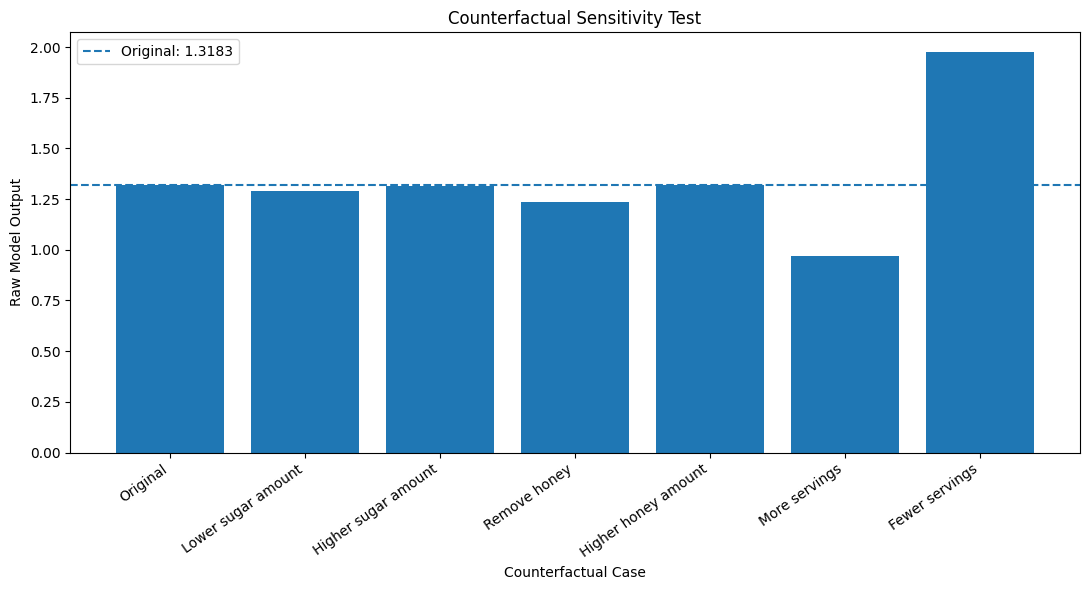

In [13]:
# ============================================================
# STAGE 10.5A — COUNTERFACTUAL XAI ANALYSIS
#
# Purpose:
# This stage tests whether the model prediction changes logically
# when ingredient amount or serving size is changed.
#
# It uses the same XAI input and prediction function as SHAP,
# LIME, and Captum:
#   - xai_display_text
#   - predict_sugar_from_texts_xai
#
# Expected behaviour:
#   Lower sugar amount    -> prediction should decrease
#   Higher sugar amount   -> prediction should increase
#   Remove honey          -> prediction should decrease
#   Higher honey amount   -> prediction should increase
#   More servings         -> prediction should decrease
#   Fewer servings        -> prediction should increase
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Safety checks
# ------------------------------------------------------------

if "xai_display_text" not in globals():
    raise NameError(
        "xai_display_text is not defined. "
        "Please run STAGE 10.1 — XAI MODEL SELECTION first."
    )

if "predict_sugar_from_texts_xai" not in globals():
    raise NameError(
        "predict_sugar_from_texts_xai is not defined. "
        "Please run STAGE 10.1 — XAI MODEL SELECTION first."
    )

if "XAI_MODEL_NAME" not in globals():
    XAI_MODEL_NAME = "selected_model"

original_text = str(xai_display_text)

print("=" * 100)
print("COUNTERFACTUAL XAI INPUT CHECK")
print("=" * 100)
print("Selected model:", XAI_MODEL_NAME)
print("\nOriginal XAI input text:")
print(original_text)


# ------------------------------------------------------------
# 2. Helper function: replace text and track success
# ------------------------------------------------------------

def replace_with_check(text, pattern, replacement):
    """
    Replace a selected value in the text.
    Also returns whether the replacement was successful.
    """
    new_text, count = re.subn(
        pattern,
        replacement,
        text,
        flags=re.IGNORECASE
    )
    return new_text, count


def create_counterfactual_texts(text):
    """
    Create controlled counterfactual samples.
    Only one selected factor is changed at a time.
    """

    counterfactuals = []

    # Original case
    counterfactuals.append({
        "Case": "Original",
        "Changed Factor": "None",
        "Counterfactual Text": text,
        "Expected Direction": "Baseline",
        "Replacement Success": "Baseline"
    })

    # --------------------------------------------------------
    # Sugar quantity changes
    # --------------------------------------------------------

    new_text, count = replace_with_check(
        text,
        r"200\s*g\s*sugar",
        "20 g sugar"
    )

    counterfactuals.append({
        "Case": "Lower sugar amount",
        "Changed Factor": "200 g sugar -> 20 g sugar",
        "Counterfactual Text": new_text,
        "Expected Direction": "Decrease",
        "Replacement Success": "Yes" if count > 0 else "No"
    })

    new_text, count = replace_with_check(
        text,
        r"200\s*g\s*sugar",
        "400 g sugar"
    )

    counterfactuals.append({
        "Case": "Higher sugar amount",
        "Changed Factor": "200 g sugar -> 400 g sugar",
        "Counterfactual Text": new_text,
        "Expected Direction": "Increase",
        "Replacement Success": "Yes" if count > 0 else "No"
    })

    # --------------------------------------------------------
    # Honey quantity changes
    # --------------------------------------------------------

    new_text, count = replace_with_check(
        text,
        r"42\s*g\s*honey",
        "0 g honey"
    )

    counterfactuals.append({
        "Case": "Remove honey",
        "Changed Factor": "42 g honey -> 0 g honey",
        "Counterfactual Text": new_text,
        "Expected Direction": "Decrease",
        "Replacement Success": "Yes" if count > 0 else "No"
    })

    new_text, count = replace_with_check(
        text,
        r"42\s*g\s*honey",
        "84 g honey"
    )

    counterfactuals.append({
        "Case": "Higher honey amount",
        "Changed Factor": "42 g honey -> 84 g honey",
        "Counterfactual Text": new_text,
        "Expected Direction": "Increase",
        "Replacement Success": "Yes" if count > 0 else "No"
    })

    # --------------------------------------------------------
    # Serving size changes
    # --------------------------------------------------------

    new_text, count = replace_with_check(
        text,
        r"servings\s*:\s*5\.?0?",
        "servings: 10.0"
    )

    counterfactuals.append({
        "Case": "More servings",
        "Changed Factor": "servings: 5.0 -> servings: 10.0",
        "Counterfactual Text": new_text,
        "Expected Direction": "Decrease",
        "Replacement Success": "Yes" if count > 0 else "No"
    })

    new_text, count = replace_with_check(
        text,
        r"servings\s*:\s*5\.?0?",
        "servings: 2.0"
    )

    counterfactuals.append({
        "Case": "Fewer servings",
        "Changed Factor": "servings: 5.0 -> servings: 2.0",
        "Counterfactual Text": new_text,
        "Expected Direction": "Increase",
        "Replacement Success": "Yes" if count > 0 else "No"
    })

    return counterfactuals


counterfactual_examples = create_counterfactual_texts(original_text)

print("\nNumber of counterfactual cases created:", len(counterfactual_examples))


# ------------------------------------------------------------
# 3. Prediction function
# ------------------------------------------------------------
# Important:
# Your current predict_sugar_from_texts_xai() returns the direct
# model output because np.expm1(preds) is commented in STAGE 10.1.
#
# Therefore, this cell keeps both:
#   1. Raw model output
#   2. Inverse-log converted value
#
# If your model was trained with log1p target, the inverse-log
# value is the human-readable sugar-per-serving value.
# ------------------------------------------------------------

def predict_single_text_counterfactual(text):
    """
    Predict one counterfactual text using the same prediction
    function used by SHAP and LIME.
    """

    raw_pred = predict_sugar_from_texts_xai([text])
    raw_pred = np.array(raw_pred)

    if raw_pred.ndim == 2:
        raw_value = float(raw_pred[0][0])
    else:
        raw_value = float(raw_pred[0])

    inverse_log_value = float(np.expm1(raw_value))

    return raw_value, inverse_log_value


# ------------------------------------------------------------
# 4. Run counterfactual predictions
# ------------------------------------------------------------

counterfactual_results = []

for item in counterfactual_examples:
    raw_pred, inverse_log_pred = predict_single_text_counterfactual(
        item["Counterfactual Text"]
    )

    counterfactual_results.append({
        "Case": item["Case"],
        "Changed Factor": item["Changed Factor"],
        "Expected Direction": item["Expected Direction"],
        "Replacement Success": item["Replacement Success"],
        "Raw Model Output": raw_pred,
        "Inverse-Log Prediction (g)": inverse_log_pred,
        "Counterfactual Text": item["Counterfactual Text"]
    })

counterfactual_df = pd.DataFrame(counterfactual_results)


# ------------------------------------------------------------
# 5. Compare against original prediction
# ------------------------------------------------------------
# Use raw model output for comparison because this matches your
# current SHAP and LIME output. The direction will remain the same
# even if inverse-log is used because expm1 is monotonic.
# ------------------------------------------------------------

PREDICTION_COLUMN_FOR_COMPARISON = "Raw Model Output"

baseline_value = counterfactual_df.loc[
    counterfactual_df["Case"] == "Original",
    PREDICTION_COLUMN_FOR_COMPARISON
].values[0]

counterfactual_df["Change from Original"] = (
    counterfactual_df[PREDICTION_COLUMN_FOR_COMPARISON] - baseline_value
)

counterfactual_df["Actual Direction"] = counterfactual_df["Change from Original"].apply(
    lambda x: "Increase" if x > 0 else ("Decrease" if x < 0 else "No Change")
)


def check_alignment(row):
    if row["Expected Direction"] == "Baseline":
        return "Baseline"
    elif row["Replacement Success"] == "No":
        return "Replacement Failed"
    elif row["Expected Direction"] == row["Actual Direction"]:
        return "Aligned"
    else:
        return "Not Aligned"


counterfactual_df["Model Behaviour"] = counterfactual_df.apply(
    check_alignment,
    axis=1
)


# ------------------------------------------------------------
# 6. Display result
# ------------------------------------------------------------

display(
    counterfactual_df[
        [
            "Case",
            "Changed Factor",
            "Replacement Success",
            "Expected Direction",
            "Raw Model Output",
            "Inverse-Log Prediction (g)",
            "Change from Original",
            "Actual Direction",
            "Model Behaviour"
        ]
    ]
)


# ------------------------------------------------------------
# 7. Simple interpretation printout
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("COUNTERFACTUAL XAI RESULT SUMMARY")
print("=" * 100)

print(f"Baseline raw model output: {baseline_value:.6f}")

aligned_count = (counterfactual_df["Model Behaviour"] == "Aligned").sum()
not_aligned_count = (counterfactual_df["Model Behaviour"] == "Not Aligned").sum()
failed_count = (counterfactual_df["Model Behaviour"] == "Replacement Failed").sum()

print("Aligned cases:", aligned_count)
print("Not aligned cases:", not_aligned_count)
print("Replacement failed cases:", failed_count)

print("\nInterpretation guide:")
print("- Aligned means the prediction changed in the expected direction.")
print("- Not Aligned means the model did not respond as expected.")
print("- Replacement Failed means the pattern was not found in the original text.")

# ------------------------------------------------------------
# 8. Plot counterfactual result
# ------------------------------------------------------------

plot_df = counterfactual_df.copy()

plt.figure(figsize=(11, 6))

plt.bar(
    plot_df["Case"],
    plot_df[PREDICTION_COLUMN_FOR_COMPARISON]
)

plt.axhline(
    baseline_value,
    linestyle="--",
    label=f"Original: {baseline_value:.4f}"
)

plt.xlabel("Counterfactual Case")
plt.ylabel(PREDICTION_COLUMN_FOR_COMPARISON)
plt.title("Counterfactual Sensitivity Test")
plt.xticks(rotation=35, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# STAGE 10.5B — SAVE COUNTERFACTUAL XAI RESULTS
#
# Purpose:
# This stage saves the output from STAGE 10.5A.
#
# Required input from STAGE 10.5A:
#   - counterfactual_df
#   - baseline_value
#   - PREDICTION_COLUMN_FOR_COMPARISON
#
# Saved outputs:
#   1. Counterfactual result table (.csv)
#   2. Counterfactual result table (.xlsx)
#   3. Counterfactual full text cases (.txt)
#   4. Counterfactual interpretation summary (.txt)
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# 1. Check required variables
# ------------------------------------------------------------

if "counterfactual_df" not in globals():
    raise NameError(
        "counterfactual_df is not found. "
        "Please run STAGE 10.5A — COUNTERFACTUAL XAI ANALYSIS first."
    )

if "PREDICTION_COLUMN_FOR_COMPARISON" not in globals():
    PREDICTION_COLUMN_FOR_COMPARISON = "Raw Model Output"

if "baseline_value" not in globals():
    baseline_value = counterfactual_df.loc[
        counterfactual_df["Case"] == "Original",
        PREDICTION_COLUMN_FOR_COMPARISON
    ].values[0]

print("=" * 100)
print("SAVE COUNTERFACTUAL XAI RESULTS")
print("=" * 100)
print("Using prediction column:", PREDICTION_COLUMN_FOR_COMPARISON)
print(f"Baseline value: {baseline_value:.6f}")


# ------------------------------------------------------------
# 2. Create output folder
# ------------------------------------------------------------

COUNTERFACTUAL_OUTPUT_DIR = "xai_counterfactual_results"
os.makedirs(COUNTERFACTUAL_OUTPUT_DIR, exist_ok=True)

print(f"\nCounterfactual output folder created: {COUNTERFACTUAL_OUTPUT_DIR}")


# ------------------------------------------------------------
# 3. Save counterfactual result table
# ------------------------------------------------------------

counterfactual_csv_path = os.path.join(
    COUNTERFACTUAL_OUTPUT_DIR,
    "counterfactual_sensitivity_results.csv"
)

counterfactual_excel_path = os.path.join(
    COUNTERFACTUAL_OUTPUT_DIR,
    "counterfactual_sensitivity_results.xlsx"
)

counterfactual_df.to_csv(counterfactual_csv_path, index=False)
counterfactual_df.to_excel(counterfactual_excel_path, index=False)

print("\nSaved counterfactual result table:")
print(counterfactual_csv_path)
print(counterfactual_excel_path)


# ------------------------------------------------------------
# 4. Save full counterfactual text cases
# ------------------------------------------------------------

counterfactual_text_path = os.path.join(
    COUNTERFACTUAL_OUTPUT_DIR,
    "counterfactual_text_cases.txt"
)

with open(counterfactual_text_path, "w", encoding="utf-8") as f:
    f.write("Counterfactual Text Cases\n")
    f.write("=" * 80 + "\n\n")

    for _, row in counterfactual_df.iterrows():
        f.write(f"Case: {row['Case']}\n")
        f.write(f"Changed Factor: {row['Changed Factor']}\n")
        f.write(f"Expected Direction: {row['Expected Direction']}\n")
        f.write(f"Actual Direction: {row['Actual Direction']}\n")
        f.write(f"Model Behaviour: {row['Model Behaviour']}\n")
        f.write("-" * 80 + "\n")
        f.write(str(row["Counterfactual Text"]))
        f.write("\n\n" + "=" * 80 + "\n\n")

print("\nSaved full counterfactual text cases:")
print(counterfactual_text_path)


# ------------------------------------------------------------
# 5. Save interpretation summary
# ------------------------------------------------------------

aligned_count = (counterfactual_df["Model Behaviour"] == "Aligned").sum()
not_aligned_count = (counterfactual_df["Model Behaviour"] == "Not Aligned").sum()
failed_count = (counterfactual_df["Model Behaviour"] == "Replacement Failed").sum()

summary_text = "Counterfactual XAI Sensitivity Test Summary\n"
summary_text += "=" * 60 + "\n\n"

summary_text += "Purpose:\n"
summary_text += (
    "This counterfactual test evaluates whether the model responds logically "
    "when sugar amount, honey amount, and serving size are changed. "
    "It is used to assess whether the model is sensitive to the quantitative "
    "relationship between ingredient amount, serving size, and sugar-per-serving prediction.\n\n"
)

summary_text += "Prediction setting:\n"
summary_text += f"- Prediction column used for comparison: {PREDICTION_COLUMN_FOR_COMPARISON}\n"
summary_text += f"- Baseline value: {baseline_value:.6f}\n\n"

if "Inverse-Log Prediction (g)" in counterfactual_df.columns:
    original_inverse_value = counterfactual_df.loc[
        counterfactual_df["Case"] == "Original",
        "Inverse-Log Prediction (g)"
    ].values[0]
    summary_text += f"- Original inverse-log prediction: {original_inverse_value:.6f} g\n\n"

summary_text += "Expected behaviour:\n"
summary_text += "- Lower sugar amount should reduce the prediction.\n"
summary_text += "- Higher sugar amount should increase the prediction.\n"
summary_text += "- Removing honey should reduce the prediction.\n"
summary_text += "- Increasing honey amount should increase the prediction.\n"
summary_text += "- Increasing serving size should reduce the sugar-per-serving prediction.\n"
summary_text += "- Reducing serving size should increase the sugar-per-serving prediction.\n\n"

summary_text += "Overall result:\n"
summary_text += f"- Aligned cases: {aligned_count}\n"
summary_text += f"- Not aligned cases: {not_aligned_count}\n"
summary_text += f"- Replacement failed cases: {failed_count}\n\n"

summary_text += "Detailed result:\n"

for _, row in counterfactual_df.iterrows():
    summary_text += (
        f"- {row['Case']}: "
        f"Changed Factor = {row['Changed Factor']}, "
        f"Expected = {row['Expected Direction']}, "
        f"Actual = {row['Actual Direction']}, "
        f"Change = {row['Change from Original']:.6f}, "
        f"Behaviour = {row['Model Behaviour']}"
    )

    if "Inverse-Log Prediction (g)" in counterfactual_df.columns:
        summary_text += (
            f", Inverse-Log Prediction = "
            f"{row['Inverse-Log Prediction (g)']:.6f} g"
        )

    summary_text += "\n"

summary_text += "\nInterpretation note:\n"
summary_text += (
    "If the prediction changes in the expected direction, this provides evidence "
    "that the model is sensitive to the intended quantitative relationship. "
    "If the prediction does not change logically, this may suggest that the model "
    "relies more on keyword-level patterns than true numerical reasoning. "
    "This test complements LIME, SHAP, and Captum because those methods explain "
    "token importance but do not fully verify whether the model understands the "
    "calculation relationship between ingredient quantity, serving size, and "
    "sugar-per-serving value.\n"
)

counterfactual_summary_path = os.path.join(
    COUNTERFACTUAL_OUTPUT_DIR,
    "counterfactual_summary.txt"
)

with open(counterfactual_summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("\nSaved counterfactual interpretation summary:")
print(counterfactual_summary_path)


# ------------------------------------------------------------
# 6. Confirm saved files
# ------------------------------------------------------------

print("\nAll counterfactual XAI result data saved successfully:")
print(f"1. CSV table   : {counterfactual_csv_path}")
print(f"2. Excel table : {counterfactual_excel_path}")
print(f"3. Text cases  : {counterfactual_text_path}")
print(f"4. Summary txt : {counterfactual_summary_path}")

SAVE COUNTERFACTUAL XAI RESULTS
Using prediction column: Raw Model Output
Baseline value: 1.318297

Counterfactual output folder created: xai_counterfactual_results

Saved counterfactual result table:
xai_counterfactual_results/counterfactual_sensitivity_results.csv
xai_counterfactual_results/counterfactual_sensitivity_results.xlsx

Saved full counterfactual text cases:
xai_counterfactual_results/counterfactual_text_cases.txt

Saved counterfactual interpretation summary:
xai_counterfactual_results/counterfactual_summary.txt

All counterfactual XAI result data saved successfully:
1. CSV table   : xai_counterfactual_results/counterfactual_sensitivity_results.csv
2. Excel table : xai_counterfactual_results/counterfactual_sensitivity_results.xlsx
3. Text cases  : xai_counterfactual_results/counterfactual_text_cases.txt
4. Summary txt : xai_counterfactual_results/counterfactual_summary.txt
